# CreditLens — Corporate Loan Portfolio Risk Analytics
### Answers to the Credit Risk Question Bank
**Dataset:** `synthetic_portfolio_risk_data.csv` (5,000 publicly traded companies)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

df = pd.read_csv('synthetic_portfolio_risk_data.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (5000, 64)


,company_id,industry_sector,revenue,cogs,gross_profit,operating_profit,net_profit,ebitda,interest_expense,total_assets,...,beta,sharpe_ratio,treynor_ratio,max_drawdown,sortino_ratio,r_squared,npl_status,cost_of_risk,is_default,portfolio_weight
0,COMP_00001,Energy,7399.91,3455.86,3944.05,2855.54,2068.75,3558.04,794.66,18634.88,...,0.6766,4.1912,0.2949,0.1719,5.6838,0.1258,0,0.0340,0,0.000525
1,COMP_00002,Consumer Discretionary,856.69,551.75,304.94,154.33,111.04,186.82,7.45,1024.58,...,1.5471,0.0770,0.0120,0.5464,0.1373,0.5737,0,0.0401,0,0.000071
2,COMP_00003,Telecom,1039.31,660.32,378.99,127.29,102.02,217.19,27.51,1894.48,...,1.2804,0.4468,0.1033,0.0951,0.7894,0.6610,0,0.0139,0,0.000045


---
## Part A — Problem Framing & Business Context
### Question 1(a): Defining the Objective

**Business Problem:**

A commercial bank holds a portfolio of corporate loans. At the **individual loan level**, the problem is binary classification: will this borrower default within the measurement horizon (typically 1 year)? This drives underwriting decisions — whether to approve, at what rate, and with what covenants.

At the **portfolio level**, the problem is risk aggregation: what is the total expected loss, how concentrated is the book, and does the capital held adequately buffer unexpected losses? Correlated defaults (e.g., in a recession) mean portfolio loss is non-linear in individual PDs.

**"Better" vs. "Worse":**

| Lens | Better | Worse |
|------|--------|-------|
| Risk-minimisation | Lower default rate, lower EL, higher DSCR across book | High concentration in distressed sectors, PD > 15% on large exposures |
| Return-maximisation | Highest risk-adjusted spread (EL-adjusted NIM), efficient capital usage | Rejecting good obligors, over-provisioning, idle capital |

**Target Variables:**
- `is_default` — binary, drives PD estimation (classification)
- `provision_for_credit_losses` — continuous, drives LGD/ECL modelling (regression)
- `days_past_due` — ordinal, drives staging (IFRS 9 Stages 1/2/3)

Multiple targets are needed because a loan can be delinquent without being technically defaulted, and the severity of loss (LGD) is independent of probability (PD).

**Corporate vs. Consumer Lending:**

| Dimension | Corporate | Consumer/P2P |
|-----------|-----------|---------------|
| Data | Rich audited financials, market prices | Bureau scores, stated income |
| LGD | Higher severity (30–70%), complex collateral | Lower severity, homogeneous pools |
| Regulation | Basel III/IV IRB, CECL, IFRS 9 — capital floors, model validation SR 11-7 | Similar CECL/IFRS 9 but simpler pools |
| Sample size | Small N (hundreds to low thousands) | Large N (millions), better for ML |

### Question 1(b): Data Attribute Categorisation

In [2]:
attribute_map = {
    'Borrower Fundamentals — Income Statement': [
        'revenue','cogs','gross_profit','operating_profit','net_profit','ebitda','interest_expense'],
    'Borrower Fundamentals — Balance Sheet': [
        'total_assets','total_liabilities','total_equity',
        'current_assets','current_liabilities','liquid_assets',
        'cash','inventory','accounts_payable'],
    'Market-Based Signals': [
        'share_price','shares_outstanding','eps','pe_ratio','dividend_yield',
        'volatility_annualized','alpha','beta','sharpe_ratio','treynor_ratio',
        'max_drawdown','sortino_ratio','r_squared','annualized_portfolio_return',
        'benchmark_return','daily_return_stdev','downside_deviation',
        'market_covariance','market_variance','correlation_to_benchmark',
        'tracking_error','historical_peak_value','historical_trough_value'],
    'Bank-Specific Loan Characteristics': [
        'total_gross_loan_amount','days_past_due','provision_for_credit_losses',
        'npl_status','cost_of_risk','portfolio_weight','var_95_amount'],
    'Derived Risk Metrics': [
        'net_profit_margin','roa','roe','cash_ratio','quick_ratio','current_ratio',
        'inventory_turnover','asset_turnover','payable_turnover',
        'debt_to_assets','debt_to_equity','interest_coverage','dscr',
        'dividends_per_share','risk_free_rate']
}

for cat, cols in attribute_map.items():
    print(f"\n{'='*60}")
    print(f" {cat}")
    print(f"{'='*60}")
    present = [c for c in cols if c in df.columns]
    print(', '.join(present))


 Borrower Fundamentals — Income Statement
revenue, cogs, gross_profit, operating_profit, net_profit, ebitda, interest_expense

 Borrower Fundamentals — Balance Sheet
total_assets, total_liabilities, total_equity, current_assets, current_liabilities, liquid_assets, cash, inventory, accounts_payable

 Market-Based Signals
share_price, shares_outstanding, eps, pe_ratio, dividend_yield, volatility_annualized, alpha, beta, sharpe_ratio, treynor_ratio, max_drawdown, sortino_ratio, r_squared, annualized_portfolio_return, benchmark_return, daily_return_stdev, downside_deviation, market_covariance, market_variance, correlation_to_benchmark, tracking_error, historical_peak_value, historical_trough_value

 Bank-Specific Loan Characteristics
total_gross_loan_amount, days_past_due, provision_for_credit_losses, npl_status, cost_of_risk, portfolio_weight, var_95_amount

 Derived Risk Metrics
net_profit_margin, roa, roe, cash_ratio, quick_ratio, current_ratio, inventory_turnover, asset_turnover, paya

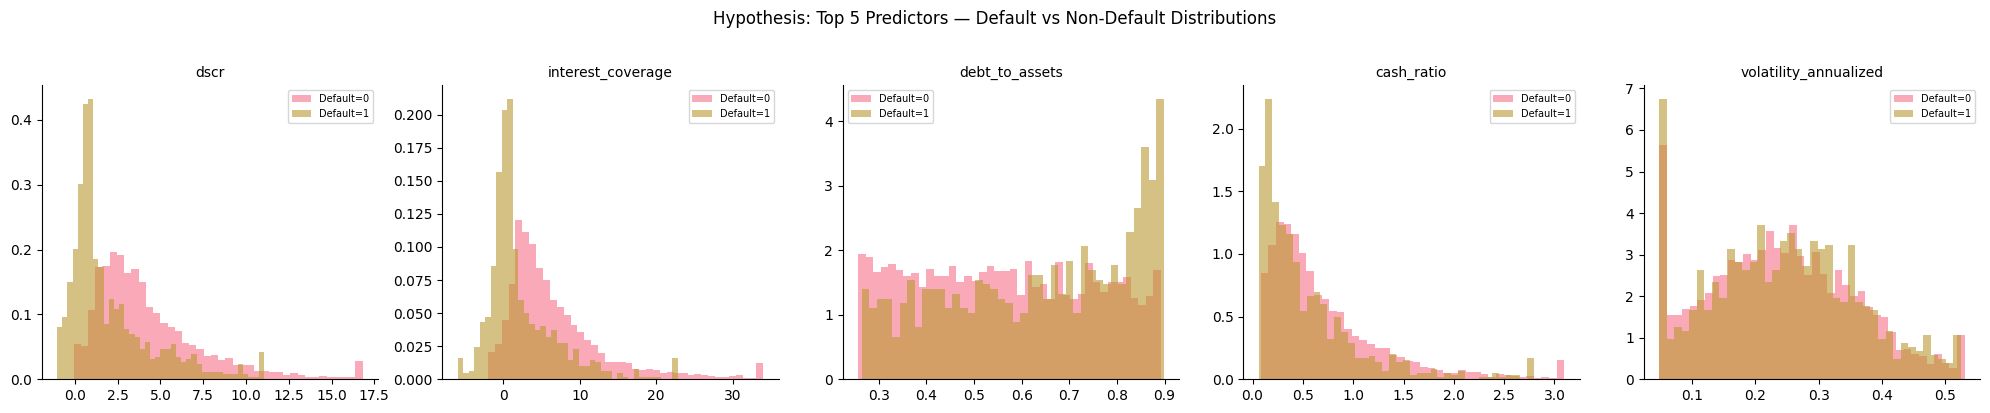

In [3]:
# Hypothesis: Top 5 most predictive of default
hypothesis_cols = ['dscr', 'interest_coverage', 'debt_to_assets', 'cash_ratio', 'volatility_annualized']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, hypothesis_cols):
    for label, grp in df.groupby('is_default'):
        vals = grp[col].replace([np.inf, -np.inf], np.nan).dropna()
        # clip for visual clarity
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(p1, p99)
        ax.hist(vals, bins=40, alpha=0.6, label=f'Default={label}', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Hypothesis: Top 5 Predictors — Default vs Non-Default Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Part B — Exploratory Data Analysis
### Question 2(i): Default Rates and Industry Patterns

In [4]:
overall_default = df['is_default'].mean()
overall_npl = df['npl_status'].mean()
print(f"Overall default rate (is_default):  {overall_default:.2%}")
print(f"Overall NPL rate   (npl_status):    {overall_npl:.2%}")
print(f"""
Why they differ:
  - 'is_default' is a binary event flag (PD horizon, e.g. 90+ DPD or credit event).
  - 'npl_status' captures non-performing status which may include restructured/watchlist
    loans not yet formally defaulted, or use a different threshold (e.g. 30 DPD).
  - In practice NPL rate >= default rate because NPL is a broader bucket.
""")

Overall default rate (is_default):  17.16%
Overall NPL rate   (npl_status):    3.62%

Why they differ:
  - 'is_default' is a binary event flag (PD horizon, e.g. 90+ DPD or credit event).
  - 'npl_status' captures non-performing status which may include restructured/watchlist
    loans not yet formally defaulted, or use a different threshold (e.g. 30 DPD).
  - In practice NPL rate >= default rate because NPL is a broader bucket.



                        count  default_rate  npl_rate
industry_sector                                      
Real Estate               445        0.1910    0.0517
Healthcare                435        0.1885    0.0529
Technology                487        0.1848    0.0349
Utilities                 448        0.1808    0.0424
Telecom                   429        0.1795    0.0373
Energy                    436        0.1766    0.0321
Financials                470        0.1702    0.0277
Materials                 468        0.1667    0.0299
Industrials               467        0.1606    0.0321
Consumer Discretionary    447        0.1454    0.0291
Consumer Staples          468        0.1453    0.0299


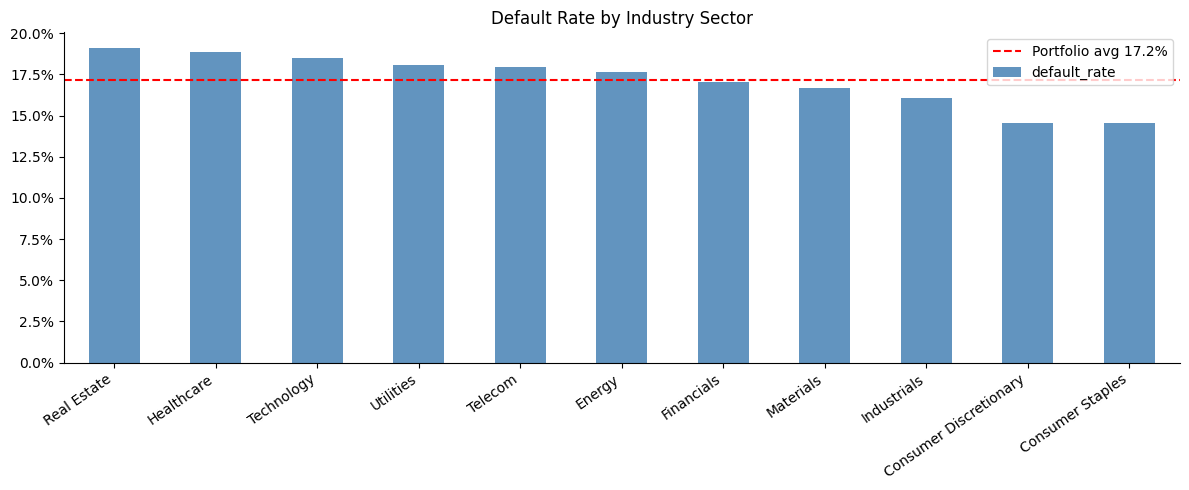

In [5]:
sector_stats = df.groupby('industry_sector').agg(
    count=('is_default','count'),
    default_rate=('is_default','mean'),
    npl_rate=('npl_status','mean')
).sort_values('default_rate', ascending=False).round(4)

print(sector_stats.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
sector_stats['default_rate'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
ax.axhline(overall_default, color='red', linestyle='--', label=f'Portfolio avg {overall_default:.1%}')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Industry Sector')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Top vs bottom sector ratio analysis
top_sector    = sector_stats.index[0]
bottom_sector = sector_stats.index[-1]

ratio_cols = ['dscr', 'interest_coverage', 'debt_to_equity']
print(f"\n=== {top_sector} (highest default) ===")
print(df[df['industry_sector'] == top_sector][ratio_cols].describe().round(3))
print(f"\n=== {bottom_sector} (lowest default) ===")
print(df[df['industry_sector'] == bottom_sector][ratio_cols].describe().round(3))


=== Real Estate (highest default) ===
          dscr  interest_coverage  debt_to_equity
count  445.000            445.000         445.000
mean     4.231              6.740           2.005
std      3.893              8.861           1.911
min     -2.289             -9.224           0.336
25%      1.814              1.801           0.689
50%      3.241              4.568           1.236
75%      5.618              9.345           2.687
max     32.247             85.287           8.831

=== Consumer Staples (lowest default) ===
          dscr  interest_coverage  debt_to_equity
count  468.000            468.000         468.000
mean     3.963              6.179           2.053
std      3.619              7.469           1.944
min     -1.322             -7.000           0.335
25%      1.555              1.637           0.638
50%      3.042              4.171           1.273
75%      5.337              8.580           2.686
max     26.737             54.993           8.890


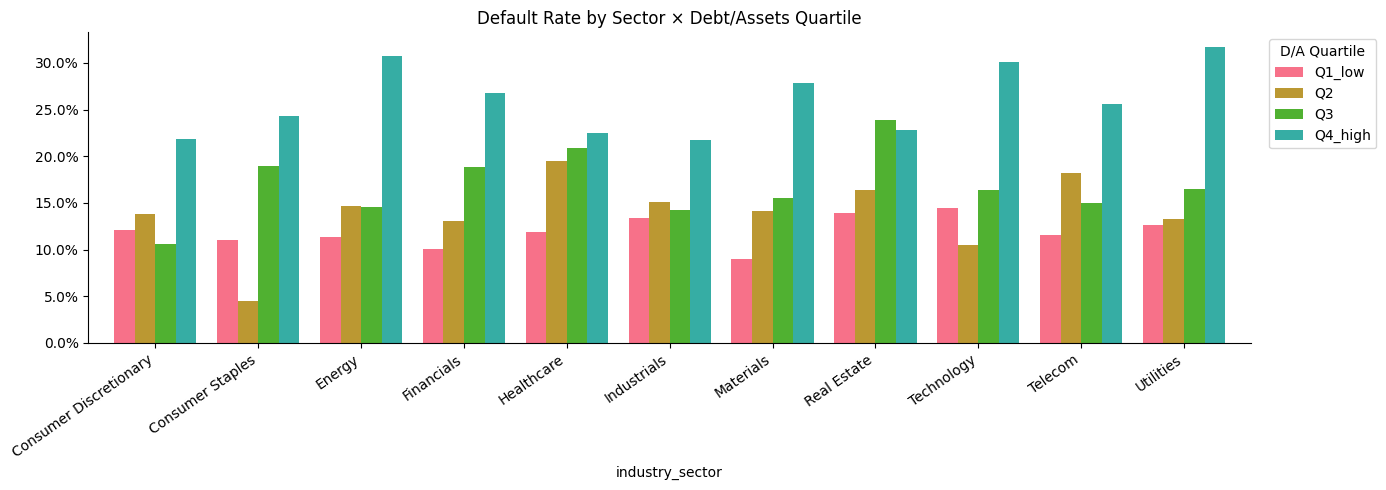

In [7]:
# Sector default rate controlling for leverage quartiles
df['dta_quartile'] = pd.qcut(df['debt_to_assets'], 4, labels=['Q1_low','Q2','Q3','Q4_high'])
pivot = df.groupby(['industry_sector','dta_quartile'])['is_default'].mean().unstack()
fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Sector × Debt/Assets Quartile')
ax.legend(title='D/A Quartile', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Question 2(ii): Loan Exposure Analysis

Loan amount distribution:
count     5000.0
mean       937.5
std       1730.6
min          3.3
25%        147.3
50%        385.3
75%        972.1
max      27828.4
Name: total_gross_loan_amount, dtype: float64


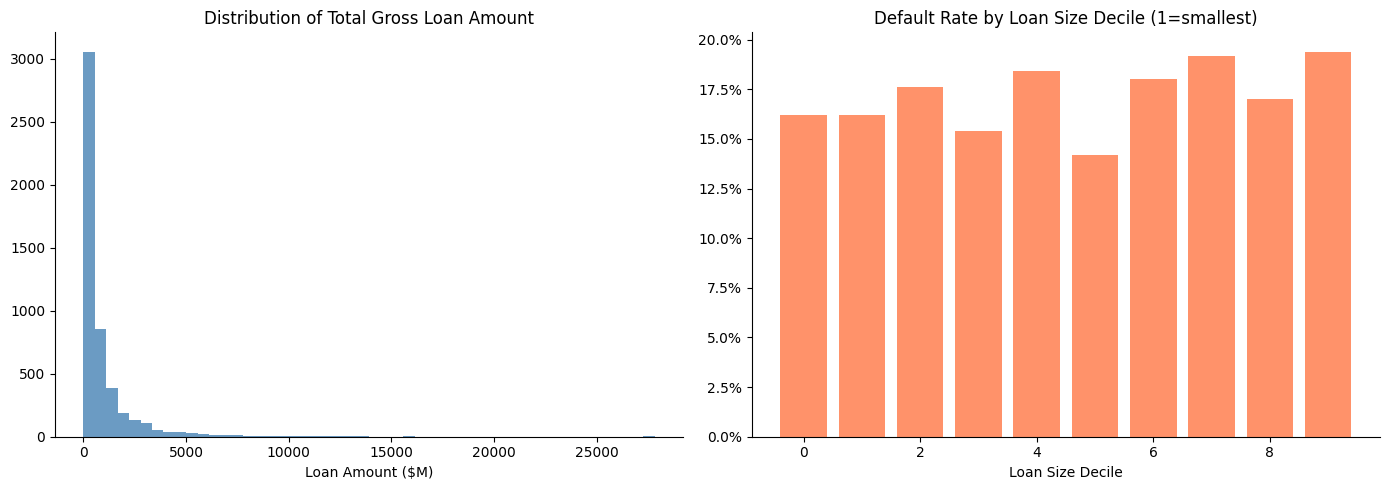

In [8]:
loan = df['total_gross_loan_amount']
print("Loan amount distribution:")
print(loan.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(loan, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Distribution of Total Gross Loan Amount')
axes[0].set_xlabel('Loan Amount ($M)')

# Loan size vs default
df['loan_decile'] = pd.qcut(loan, 10, labels=False)
loan_default = df.groupby('loan_decile')['is_default'].mean()
axes[1].bar(range(10), loan_default, color='coral', alpha=0.85)
axes[1].set_title('Default Rate by Loan Size Decile (1=smallest)')
axes[1].set_xlabel('Loan Size Decile')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


Sector shares:
industry_sector
Materials                 9.83%
Industrials               9.74%
Technology                9.58%
Financials                9.29%
Healthcare                9.26%
Real Estate               9.22%
Consumer Staples          9.08%
Consumer Discretionary    8.95%
Energy                    8.70%
Telecom                   8.50%
Utilities                 7.86%

Herfindahl-Hirschman Index (HHI): 0.0912
  HHI < 0.15  → Unconcentrated (competitive)
  0.15–0.25   → Moderate concentration
  > 0.25      → Highly concentrated
  Portfolio: Unconcentrated


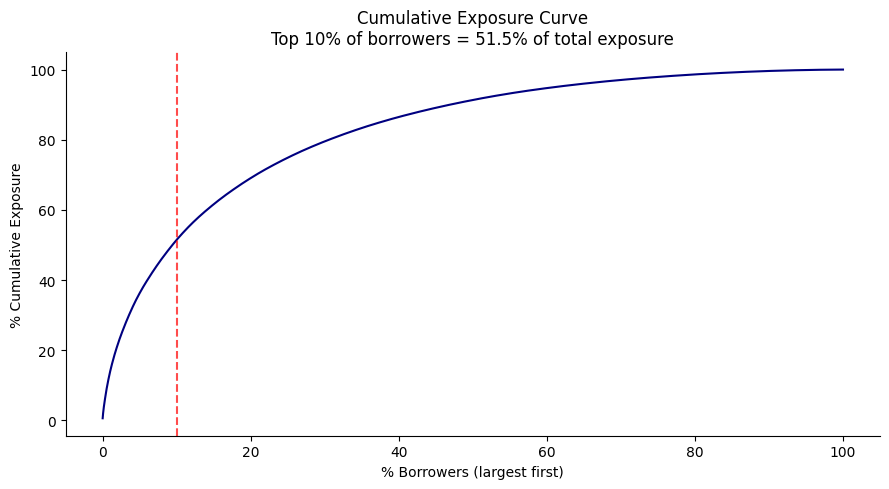

In [9]:
# Herfindahl-Hirschman Index by sector
total_exposure = loan.sum()
sector_exposure = df.groupby('industry_sector')['total_gross_loan_amount'].sum()
sector_share = sector_exposure / total_exposure
HHI = (sector_share ** 2).sum()
print(f"\nSector shares:")
print(sector_share.sort_values(ascending=False).apply(lambda x: f'{x:.2%}').to_string())
print(f"\nHerfindahl-Hirschman Index (HHI): {HHI:.4f}")
print(f"  HHI < 0.15  → Unconcentrated (competitive)")
print(f"  0.15–0.25   → Moderate concentration")
print(f"  > 0.25      → Highly concentrated")
level = 'Unconcentrated' if HHI < 0.15 else ('Moderately concentrated' if HHI < 0.25 else 'Highly concentrated')
print(f"  Portfolio: {level}")

# Cumulative exposure curve
sorted_loan = loan.sort_values(ascending=False).reset_index(drop=True)
cum_exposure = sorted_loan.cumsum() / total_exposure
cum_pct_borrowers = (sorted_loan.index + 1) / len(sorted_loan)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cum_pct_borrowers * 100, cum_exposure * 100, color='navy')
ax.axvline(10, color='red', linestyle='--', alpha=0.7)
pct_top10 = cum_exposure.iloc[int(0.10 * len(sorted_loan))]
ax.set_title(f'Cumulative Exposure Curve\nTop 10% of borrowers = {pct_top10:.1%} of total exposure')
ax.set_xlabel('% Borrowers (largest first)')
ax.set_ylabel('% Cumulative Exposure')
plt.tight_layout()
plt.show()

### Question 2(iii): Interest Expense & Debt Servicing

In [10]:
ic = df['interest_coverage'].replace([np.inf, -np.inf], np.nan)
below_1_5 = (ic < 1.5).sum() / ic.notna().sum()
print(f"Interest coverage < 1.5x (distress threshold): {below_1_5:.2%} of portfolio")

# DSCR by sector
dscr_sector = df.groupby('industry_sector')['dscr'].agg(['mean','median','std','min','max']).round(3)
print("\nDSCR by sector:")
print(dscr_sector.to_string())

Interest coverage < 1.5x (distress threshold): 22.46% of portfolio

DSCR by sector:
                         mean  median    std    min     max
industry_sector                                            
Consumer Discretionary  3.852   3.058  3.357 -3.192  18.937
Consumer Staples        3.963   3.042  3.619 -1.322  26.737
Energy                  3.956   3.097  3.535 -1.004  28.642
Financials              3.811   2.961  3.033 -1.602  21.733
Healthcare              3.849   3.189  3.096 -1.022  16.936
Industrials             3.939   3.109  3.392 -0.667  26.195
Materials               3.818   3.085  3.484 -1.643  34.258
Real Estate             4.231   3.241  3.893 -2.289  32.247
Technology              3.872   3.153  3.211 -1.150  22.744
Telecom                 3.947   3.192  3.179 -0.712  27.156
Utilities               4.138   3.361  3.334 -0.770  19.625


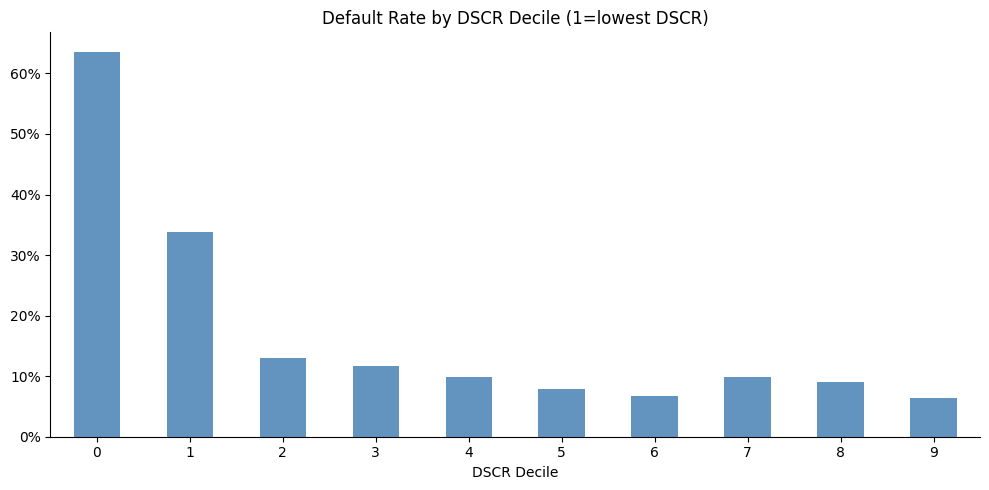

Single-variable AUC (interest_coverage): 0.7624
Single-variable AUC (dscr): 0.7586


In [11]:
# Default rate by DSCR decile
df['dscr_clipped'] = df['dscr'].clip(df['dscr'].quantile(0.01), df['dscr'].quantile(0.99))
df['dscr_decile'] = pd.qcut(df['dscr_clipped'], 10, labels=False, duplicates='drop')
dscr_default = df.groupby('dscr_decile')['is_default'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
dscr_default.plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by DSCR Decile (1=lowest DSCR)')
ax.set_xlabel('DSCR Decile')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ROC-AUC for single-variable classifiers: interest_coverage vs dscr
mask = df[['interest_coverage','dscr','is_default']].replace([np.inf,-np.inf], np.nan).dropna().index
y_true = df.loc[mask, 'is_default']

for col in ['interest_coverage','dscr']:
    score = -df.loc[mask, col]   # negate: lower ratio → higher default risk
    auc = roc_auc_score(y_true, score)
    print(f"Single-variable AUC ({col}): {auc:.4f}")

### Question 2(iv): Leverage and Capital Structure

Correlation between derived D/E and actual D/E: 1.0000
=> They are mathematically equivalent (perfect correlation expected in clean data).

Default rate by leverage bucket:
leverage_bucket
Low (<0.4)           11.98%
Medium (0.4-0.65)    14.00%
High (>0.65)         23.56%


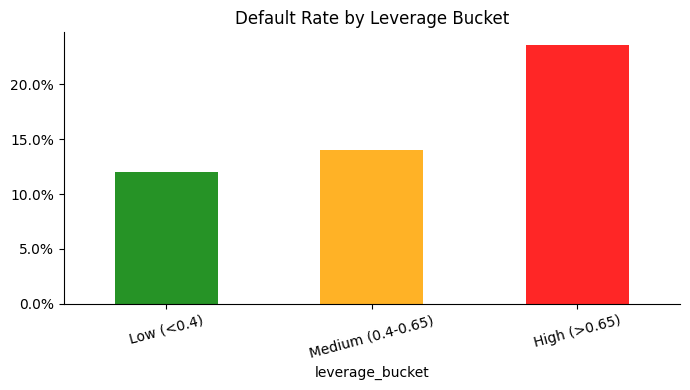

In [12]:
# Mathematical relationship: D/E = (D/A) / (1 - D/A)
df['dta_derived_de'] = df['debt_to_assets'] / (1 - df['debt_to_assets'])
corr = df['dta_derived_de'].corr(df['debt_to_equity'])
print(f"Correlation between derived D/E and actual D/E: {corr:.4f}")
print("=> They are mathematically equivalent (perfect correlation expected in clean data).")

# Leverage buckets
bins = [0, 0.4, 0.65, 1.0]
labels = ['Low (<0.4)', 'Medium (0.4-0.65)', 'High (>0.65)']
df['leverage_bucket'] = pd.cut(df['debt_to_assets'], bins=bins, labels=labels)
lev_default = df.groupby('leverage_bucket')['is_default'].mean()
print("\nDefault rate by leverage bucket:")
print(lev_default.apply(lambda x: f'{x:.2%}').to_string())

fig, ax = plt.subplots(figsize=(7, 4))
lev_default.plot(kind='bar', ax=ax, color=['green','orange','red'], alpha=0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Leverage Bucket')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [13]:
# Within high-leverage: which ratio best discriminates?
high_lev = df[df['debt_to_assets'] > 0.65].copy()
high_lev_clean = high_lev[['cash_ratio','current_ratio','interest_coverage','is_default']]\
    .replace([np.inf,-np.inf], np.nan).dropna()

y_hl = high_lev_clean['is_default']
for col in ['cash_ratio','current_ratio','interest_coverage']:
    auc = roc_auc_score(y_hl, -high_lev_clean[col])
    print(f"  High-leverage subset AUC ({col}): {auc:.4f}")

  High-leverage subset AUC (cash_ratio): 0.6288
  High-leverage subset AUC (current_ratio): 0.6437
  High-leverage subset AUC (interest_coverage): 0.7415


Altman Z-Score proxy AUC: 0.5984


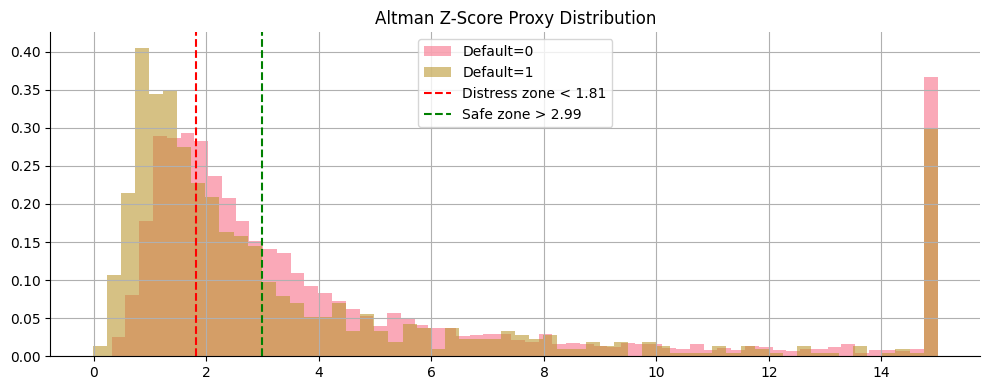

In [14]:
# Altman Z-Score proxy
# Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
# X1 = working capital / total assets
# X2 = retained earnings / total assets  (proxy: net_profit / total_assets * 5-year factor, use net_profit/assets)
# X3 = EBIT / total assets
# X4 = market cap / total liabilities
# X5 = revenue / total assets

df2 = df.copy()
df2['market_cap'] = df2['share_price'] * df2['shares_outstanding']
df2['X1'] = (df2['current_assets'] - df2['current_liabilities']) / df2['total_assets']
df2['X2'] = df2['net_profit'] / df2['total_assets']        # retained earnings proxy
df2['X3'] = df2['operating_profit'] / df2['total_assets']  # EBIT proxy
df2['X4'] = df2['market_cap'] / df2['total_liabilities'].replace(0, np.nan)
df2['X5'] = df2['revenue'] / df2['total_assets']

df2['altman_z'] = (1.2*df2['X1'] + 1.4*df2['X2'] + 3.3*df2['X3'] +
                   0.6*df2['X4'] + 1.0*df2['X5'])

clean_z = df2[['altman_z','is_default']].replace([np.inf,-np.inf], np.nan).dropna()
auc_z = roc_auc_score(clean_z['is_default'], -clean_z['altman_z'])
print(f"Altman Z-Score proxy AUC: {auc_z:.4f}")

# Distribution
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in clean_z.groupby('is_default'):
    grp['altman_z'].clip(-5, 15).hist(bins=60, alpha=0.6, label=f'Default={label}', ax=ax, density=True)
ax.axvline(1.81, color='red', linestyle='--', label='Distress zone < 1.81')
ax.axvline(2.99, color='green', linestyle='--', label='Safe zone > 2.99')
ax.set_title('Altman Z-Score Proxy Distribution')
ax.legend()
plt.tight_layout()
plt.show()

### Question 2(v): Liquidity Analysis

Liquidity ratio distributions (conservatism: cash_ratio < quick_ratio < current_ratio):


       cash_ratio  quick_ratio  current_ratio
count    5000.000     5000.000       5000.000
mean        0.696        1.456          2.153
std         0.604        1.042          1.422
min         0.032        0.126          0.293
25%         0.294        0.727          1.157
50%         0.515        1.175          1.772
75%         0.895        1.867          2.776
max         6.610        9.193         11.585

Median by default status:
            cash_ratio  quick_ratio  current_ratio
is_default                                        
0                0.540        1.229          1.848
1                0.376        0.912          1.422


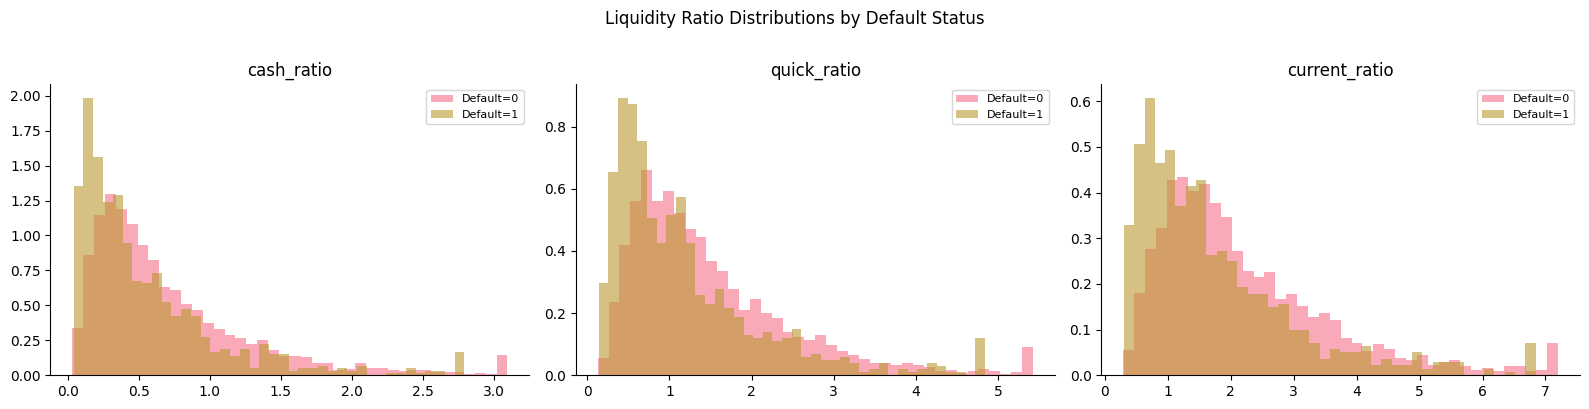

In [15]:
liq_cols = ['cash_ratio', 'quick_ratio', 'current_ratio']
print("Liquidity ratio distributions (conservatism: cash_ratio < quick_ratio < current_ratio):")
print(df[liq_cols].describe().round(3))

# Default vs non-default median
print("\nMedian by default status:")
print(df.groupby('is_default')[liq_cols].median().round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, liq_cols):
    for label, grp in df.groupby('is_default'):
        vals = grp[col].clip(0, grp[col].quantile(0.99))
        ax.hist(vals, bins=40, alpha=0.6, label=f'Default={label}', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Liquidity Ratio Distributions by Default Status', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Liquidity trap: high current_ratio but low cash_ratio
median_cr  = df['current_ratio'].median()
median_csh = df['cash_ratio'].median()

df['liquidity_trap'] = ((df['current_ratio'] > median_cr) &
                        (df['cash_ratio']    < median_csh)).astype(int)

trap_rate = df.groupby('liquidity_trap')['is_default'].mean()
print(f"Default rate — no trap : {trap_rate[0]:.2%}")
print(f"Default rate — trap    : {trap_rate[1]:.2%}")

# Liquidity gap
df['liquidity_gap'] = df['current_ratio'] - df['cash_ratio']
clean_gap = df[['liquidity_gap','is_default']].replace([np.inf,-np.inf], np.nan).dropna()
auc_gap = roc_auc_score(clean_gap['is_default'], clean_gap['liquidity_gap'])
print(f"\nLiquidity gap AUC (positive gap → higher risk): {auc_gap:.4f}")

Default rate — no trap : 17.71%
Default rate — trap    : 12.91%

Liquidity gap AUC (positive gap → higher risk): 0.3918


### Question 2(vi): Profitability and Efficiency

In [17]:
profit_cols = ['net_profit_margin', 'roa', 'roe']
eff_cols    = ['asset_turnover', 'inventory_turnover', 'payable_turnover']

print("Profitability by default status:")
print(df.groupby('is_default')[profit_cols].describe().round(3))

# ROE vs leverage
print("\nROE by leverage bucket (showing leverage distortion):")
print(df.groupby('leverage_bucket')['roe'].median().round(3))

Profitability by default status:
           net_profit_margin                                                   \
                       count   mean    std    min    25%    50%    75%    max   
is_default                                                                      
0                     4142.0  0.178  0.111 -0.108  0.094  0.176  0.259  0.481   
1                      858.0  0.076  0.121 -0.112 -0.016  0.043  0.157  0.460   

               roa         ...                   roe                       \
             count   mean  ...    75%    max   count   mean    std    min   
is_default                 ...                                              
0           4142.0  0.107  ...  0.149  0.505  4142.0  0.323  0.356 -0.576   
1            858.0  0.046  ...  0.079  0.418   858.0  0.203  0.433 -0.656   

                                        
              25%    50%    75%    max  
is_default                              
0           0.109  0.219  0.426  4.283  
1          

In [18]:
# Efficiency ratios vs default
print("Efficiency ratios by default status (median):")
print(df.groupby('is_default')[eff_cols].median().round(3))

# Profitability score
for col in profit_cols + eff_cols:
    df[col] = df[col].replace([np.inf,-np.inf], np.nan)

scaler = StandardScaler()
score_cols = ['net_profit_margin','roa','asset_turnover']
clean_score = df[score_cols + ['is_default']].dropna()
clean_score['profitability_score'] = scaler.fit_transform(clean_score[score_cols]).mean(axis=1)

for col in score_cols + ['profitability_score']:
    auc_p = roc_auc_score(clean_score['is_default'], -clean_score[col])
    print(f"  AUC ({col}): {auc_p:.4f}")

Efficiency ratios by default status (median):
            asset_turnover  inventory_turnover  payable_turnover
is_default                                                      
0                    0.531                4.51             4.067
1                    0.510                5.92             3.898
  AUC (net_profit_margin): 0.7413
  AUC (roa): 0.7406
  AUC (asset_turnover): 0.5258
  AUC (profitability_score): 0.7249


### Question 2(vii): Market-Based Risk Indicators

In [19]:
market_cols = ['beta', 'volatility_annualized', 'max_drawdown']
print("Market indicators by default status (mean):")
print(df.groupby('is_default')[market_cols].mean().round(4))

# AUC for each
for col, direction in [('beta', 1), ('volatility_annualized', 1), ('max_drawdown', 1)]:
    clean = df[[col,'is_default']].replace([np.inf,-np.inf],np.nan).dropna()
    auc_m = roc_auc_score(clean['is_default'], direction * clean[col])
    print(f"  AUC ({col}): {auc_m:.4f}")

# High drawdown
high_dd = df[df['max_drawdown'] > 0.50]['is_default'].mean()
print(f"\nDefault rate for max_drawdown > 50%: {high_dd:.2%}")

Market indicators by default status (mean):
              beta  volatility_annualized  max_drawdown
is_default                                             
0           0.9999                 0.2411        0.3780
1           0.9797                 0.2438        0.3651
  AUC (beta): 0.4865
  AUC (volatility_annualized): 0.5070
  AUC (max_drawdown): 0.4800

Default rate for max_drawdown > 50%: 16.14%


In [20]:
# Distance-to-Default (Merton model approximation)
# V_E = market cap, sigma_E = equity vol
# DD ≈ (ln(V_E/D) + (r - 0.5*sigma_V^2)*T) / (sigma_V * sqrt(T))
# Simplified: DD = (ln(market_cap / total_liabilities)) / volatility_annualized

df2['DD'] = np.log(df2['market_cap'] / df2['total_liabilities'].replace(0, np.nan)) \
            / df2['volatility_annualized'].replace(0, np.nan)

clean_dd = df2[['DD','is_default']].replace([np.inf,-np.inf],np.nan).dropna()
auc_dd = roc_auc_score(clean_dd['is_default'], -clean_dd['DD'])
print(f"Distance-to-Default (Merton proxy) AUC: {auc_dd:.4f}")

# Compare to simple ratio
clean_dta = df[['debt_to_assets','is_default']].replace([np.inf,-np.inf],np.nan).dropna()
auc_dta = roc_auc_score(clean_dta['is_default'], clean_dta['debt_to_assets'])
print(f"Simple debt_to_assets AUC:               {auc_dta:.4f}")

Distance-to-Default (Merton proxy) AUC: 0.5344
Simple debt_to_assets AUC:               0.6144


### Question 2(viii): Portfolio Risk Metrics

In [21]:
port_cols = ['sharpe_ratio', 'sortino_ratio', 'alpha', 'r_squared']

# Negative Sharpe ratio
neg_sharpe = (df['sharpe_ratio'] < 0).mean()
print(f"Proportion with negative Sharpe ratio: {neg_sharpe:.2%}")

# Alpha vs default
print("\nAlpha mean by default status:")
print(df.groupby('is_default')['alpha'].mean().round(4))

# R-squared: idiosyncratic risk
df['low_rsq'] = (df['r_squared'] < df['r_squared'].median()).astype(int)
print("\nDefault rate — low R² (idiosyncratic):")
print(df.groupby('low_rsq')['is_default'].mean().apply(lambda x: f'{x:.2%}'))

# Portfolio weighted average beta
wt_beta = (df['portfolio_weight'] * df['beta']).sum() / df['portfolio_weight'].sum()
print(f"\nPortfolio weighted average beta: {wt_beta:.4f}")
tone = 'CYCLICAL tilt' if wt_beta > 1.0 else 'DEFENSIVE tilt'
print(f"Interpretation: {tone}")

Proportion with negative Sharpe ratio: 39.74%

Alpha mean by default status:
is_default
0    0.0081
1    0.0073
Name: alpha, dtype: float64

Default rate — low R² (idiosyncratic):
low_rsq
0    17.88%
1    16.44%
Name: is_default, dtype: object

Portfolio weighted average beta: 1.0020
Interpretation: CYCLICAL tilt


### Question 2(b): Missing Values & Data Quality

In [22]:
# Identify missing / infinite values
df_quality = df.replace([np.inf, -np.inf], np.nan)
missing = df_quality.isnull().sum()
missing_pct = (missing / len(df_quality) * 100).round(2)
quality_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
quality_df = quality_df[quality_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if len(quality_df) > 0:
    print("Columns with missing/infinite values:")
    print(quality_df.to_string())
else:
    # PE ratio: negative EPS causes meaningless PE
    df_quality['pe_ratio_inf'] = df['pe_ratio'].isin([np.inf, -np.inf]) | (df['eps'] <= 0)
    print("No NaN found — checking for logically invalid PE ratios (EPS ≤ 0):")
    print(f"  Rows with EPS ≤ 0: {(df['eps'] <= 0).sum()} ({(df['eps']<=0).mean():.1%})")
    print(f"  Default rate when EPS ≤ 0: {df[df['eps']<=0]['is_default'].mean():.2%}")
    print(f"  Default rate when EPS > 0:  {df[df['eps']>0]['is_default'].mean():.2%}")
    print("\nConclusion: EPS ≤ 0 is itself a distress signal — create binary flag.")

# Binary indicator test
df_quality['neg_eps_flag'] = (df['eps'] <= 0).astype(int)
auc_eps = roc_auc_score(df['is_default'], df_quality['neg_eps_flag'])
print(f"\nAUC of neg_eps_flag: {auc_eps:.4f}")

Columns with missing/infinite values:
          missing_count  missing_pct
pe_ratio            487         9.74

AUC of neg_eps_flag: 0.6375


### Question 2(c): Data Leakage

**Variables NOT available at loan origination (leakage risk):**

| Variable | Reason |
|----------|--------|
| `days_past_due` | Post-origination outcome |
| `provision_for_credit_losses` | Set by bank after distress observed |
| `npl_status` | Outcome variable (realised) |
| `is_default` | Primary target — never use as feature |
| `portfolio_weight` | Bank internal allocation, post-decision |
| `cost_of_risk` | Derived from provisions (post-origination) |
| `var_95_amount` | Requires current market prices — may use same-period data |

**Market data temporal mismatch:**  
- `share_price`, `beta`, `volatility_annualized` change continuously. A model trained on year-end 2022 market data to predict 2023 defaults must lag all market features to the loan snapshot date.

**Proper temporal split design:**
- Train: financial ratios and market data from T (e.g. 2022 year-end)
- Target: `is_default` observed over T to T+12 months (2023)
- All market variables should be from T, not T+12

---
## Part C — Feature Engineering & Selection
### Question 3: Univariate Analysis

Top 20 univariate AUC scores:
interest_coverage      0.7624
dscr                   0.7586
net_profit_margin      0.7413
roa                    0.7406
operating_profit       0.6982
net_profit             0.6981
roe                    0.6863
eps                    0.6828
ebitda                 0.6616
current_ratio          0.6236
quick_ratio            0.6206
cash_ratio             0.6164
debt_to_assets         0.6144
debt_to_equity         0.6144
inventory_turnover     0.5999
gross_profit           0.5692
pe_ratio               0.5635
interest_expense       0.5525
current_liabilities    0.5502
accounts_payable       0.5482


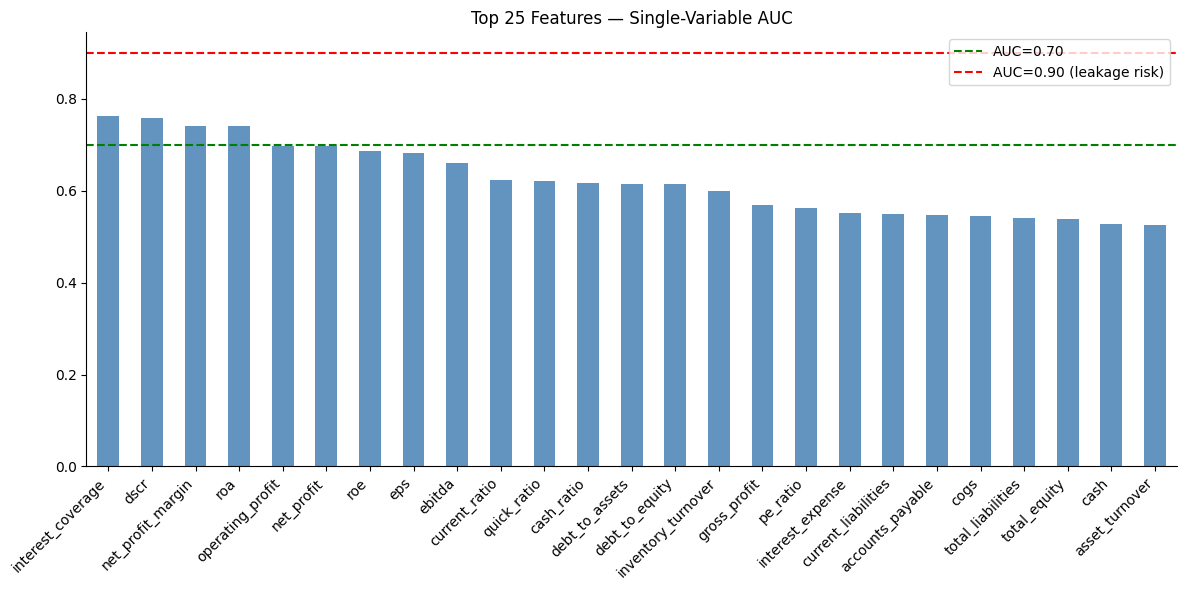

In [23]:
# Exclude leakage variables and target from features
exclude = ['company_id','industry_sector','is_default','npl_status',
           'days_past_due','provision_for_credit_losses','cost_of_risk',
           'portfolio_weight','dta_quartile','loan_decile','leverage_bucket',
           'dscr_decile','dscr_clipped','liquidity_trap','liquidity_gap',
           'low_rsq','dta_derived_de','neg_eps_flag']

feature_cols = [c for c in df.columns if c not in exclude]
df_feat = df[feature_cols + ['is_default']].replace([np.inf,-np.inf], np.nan)

# Drop rows with >50% missing
df_feat = df_feat.dropna(thresh=int(0.5 * df_feat.shape[1]))

# For each continuous feature compute single-variable AUC
auc_results = {}
for col in feature_cols:
    clean = df_feat[[col,'is_default']].dropna()
    if len(clean) < 100 or clean[col].nunique() < 5:
        continue
    try:
        auc_pos = roc_auc_score(clean['is_default'], clean[col])
        auc_results[col] = max(auc_pos, 1 - auc_pos)  # reflect to always > 0.5
    except Exception:
        pass

auc_series = pd.Series(auc_results).sort_values(ascending=False)
print("Top 20 univariate AUC scores:")
print(auc_series.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
auc_series.head(25).plot(kind='bar', ax=ax, color='steelblue', alpha=0.85)
ax.axhline(0.7, color='green', linestyle='--', label='AUC=0.70')
ax.axhline(0.9, color='red', linestyle='--', label='AUC=0.90 (leakage risk)')
ax.set_title('Top 25 Features — Single-Variable AUC')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# Weight of Evidence & Information Value
def compute_iv(df_in, feature, target='is_default', n_bins=10):
    tmp = df_in[[feature, target]].dropna().copy()
    tmp[feature] = tmp[feature].replace([np.inf,-np.inf], np.nan)
    tmp = tmp.dropna()
    try:
        tmp['bin'] = pd.qcut(tmp[feature], n_bins, duplicates='drop')
    except Exception:
        return np.nan
    total_1 = tmp[target].sum()
    total_0 = (1 - tmp[target]).sum()
    if total_1 == 0 or total_0 == 0:
        return np.nan
    g = tmp.groupby('bin')[target].agg(['sum','count'])
    g.columns = ['events','total']
    g['non_events'] = g['total'] - g['events']
    g['pct_events']     = g['events']     / total_1
    g['pct_non_events'] = g['non_events'] / total_0
    g = g[(g['pct_events'] > 0) & (g['pct_non_events'] > 0)]
    g['woe'] = np.log(g['pct_events'] / g['pct_non_events'])
    g['iv']  = (g['pct_events'] - g['pct_non_events']) * g['woe']
    return g['iv'].sum()

iv_results = {col: compute_iv(df_feat, col) for col in feature_cols}
iv_series = pd.Series(iv_results).dropna().sort_values(ascending=False)

print("Top 20 IV scores:")
print(iv_series.head(20).round(4).to_string())
print(f"\nStrong predictors (IV > 0.3): {iv_series[iv_series > 0.3].index.tolist()}")

Top 20 IV scores:
interest_coverage      1.1616
dscr                   1.1578
roa                    0.9771
net_profit_margin      0.9248
roe                    0.7996
net_profit             0.7172
operating_profit       0.7172
eps                    0.6967
ebitda                 0.4551
current_ratio          0.2395
quick_ratio            0.2275
cash_ratio             0.2092
debt_to_assets         0.2080
debt_to_equity         0.2080
inventory_turnover     0.1340
pe_ratio               0.1051
gross_profit           0.0662
interest_expense       0.0534
current_liabilities    0.0510
total_equity           0.0509

Strong predictors (IV > 0.3): ['interest_coverage', 'dscr', 'roa', 'net_profit_margin', 'roe', 'net_profit', 'operating_profit', 'eps', 'ebitda']


### Question 3(b): Derived Features

In [25]:
# Feature 1: Altman Z-Score proxy (already built in df2)
df['altman_z']         = df2['altman_z']

# Feature 2: Debt service buffer
df['dscr_buffer']      = df['dscr'] - 1.0

# Feature 3: Cash burn rate
df['cash_burn']        = df['cash'] / df['operating_profit'].replace(0, np.nan)

# Feature 4: Market-implied leverage
df2['market_cap']      = df['share_price'] * df['shares_outstanding']
df['mkt_implied_lev']  = df['total_liabilities'] / \
    (df2['market_cap'] + df['total_liabilities']).replace(0, np.nan)

# Feature 5: Return-to-risk efficiency
df['roa_vol_ratio']    = df['roa'] / df['volatility_annualized'].replace(0, np.nan)

derived = ['altman_z','dscr_buffer','cash_burn','mkt_implied_lev','roa_vol_ratio']

print("Derived features — AUC vs is_default:")
for col in derived:
    clean = df[[col,'is_default']].replace([np.inf,-np.inf],np.nan).dropna()
    auc_d = roc_auc_score(clean['is_default'], clean[col])
    auc_d = max(auc_d, 1 - auc_d)
    print(f"  {col:25s}  AUC={auc_d:.4f}")

Derived features — AUC vs is_default:
  altman_z                   AUC=0.5984
  dscr_buffer                AUC=0.7586
  cash_burn                  AUC=0.5818
  mkt_implied_lev            AUC=0.5340
  roa_vol_ratio              AUC=0.7315


---
## Part D — Predictive Modeling
### Question 4: Train/Validation Split & Evaluation Framework

In [26]:
# Build clean modelling frame (no leakage columns)
model_exclude = ['company_id','industry_sector','is_default','npl_status',
                 'days_past_due','provision_for_credit_losses','cost_of_risk',
                 'portfolio_weight','dta_quartile','loan_decile','leverage_bucket',
                 'dscr_decile','dscr_clipped','liquidity_trap','liquidity_gap',
                 'low_rsq','dta_derived_de']

model_features = [c for c in df.columns if c not in model_exclude]
df_model = df[model_features + ['is_default']].replace([np.inf,-np.inf], np.nan)

# Fill remaining NaN with median (simple imputation)
for col in model_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[model_features]
y = df_model['is_default']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.2%}  |  Test default rate: {y_test.mean():.2%}")

# Baseline: always predict non-default
baseline_acc = 1 - y_test.mean()
print(f"\nBaseline accuracy (predict all non-default): {baseline_acc:.2%}")
print("=> Accuracy is misleading — a trivial model achieves high accuracy.")
print("   Prioritise AUC-ROC, AUC-PR, and Recall (missing a default is expensive).")

Train size: 4,000  |  Test size: 1,000
Train default rate: 17.15%  |  Test default rate: 17.20%

Baseline accuracy (predict all non-default): 82.80%
=> Accuracy is misleading — a trivial model achieves high accuracy.
   Prioritise AUC-ROC, AUC-PR, and Recall (missing a default is expensive).


### Question 5: Logistic Regression Baseline

In [27]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, C=0.1, random_state=42)
lr.fit(X_train_sc, y_train)

y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
pr_lr     = average_precision_score(y_test, y_prob_lr)

print(f"Logistic Regression — AUC-ROC: {auc_lr:.4f}  |  AUC-PR: {pr_lr:.4f}")

# Top coefficients
coef_df = pd.DataFrame({'feature': model_features, 'coef': lr.coef_[0]})\
    .sort_values('coef', key=abs, ascending=False)
print("\nTop 15 coefficients (scaled):")
print(coef_df.head(15).to_string(index=False))

Logistic Regression — AUC-ROC: 0.7798  |  AUC-PR: 0.5153

Top 15 coefficients (scaled):
                 feature      coef
       net_profit_margin -0.961301
          debt_to_equity  0.417209
       total_liabilities -0.351492
                  ebitda -0.316033
            gross_profit  0.283772
        interest_expense  0.249583
 total_gross_loan_amount  0.232196
       interest_coverage -0.230765
     current_liabilities  0.220612
                     roa  0.217304
            sharpe_ratio  0.194766
           roa_vol_ratio -0.188577
            total_assets -0.162975
                     roe  0.155597
correlation_to_benchmark  0.142335


In [28]:
# VIF for multicollinearity
# Use a subset of most important features to keep VIF tractable
vif_features = coef_df.head(15)['feature'].tolist()
X_vif = X_train[vif_features].fillna(0)
X_vif_const = np.column_stack([np.ones(len(X_vif)), X_vif])

vif_vals = [variance_inflation_factor(X_vif_const, i+1) for i in range(len(vif_features))]
vif_df = pd.DataFrame({'feature': vif_features, 'VIF': vif_vals}).sort_values('VIF', ascending=False)
print("VIF for top 15 features:")
print(vif_df.round(2).to_string(index=False))
print("\nVIF > 10 indicates severe multicollinearity — consider removing or PCA.")

VIF for top 15 features:
                 feature   VIF
            gross_profit 27.51
       total_liabilities 23.48
                  ebitda 19.06
            total_assets 18.03
     current_liabilities 11.76
                     roa 10.97
        interest_expense  8.18
                     roe  5.65
 total_gross_loan_amount  3.95
       net_profit_margin  3.68
       interest_coverage  2.99
          debt_to_equity  2.68
           roa_vol_ratio  1.73
            sharpe_ratio  1.02
correlation_to_benchmark  1.00

VIF > 10 indicates severe multicollinearity — consider removing or PCA.


### Question 6(a): Decision Tree

 max_depth  train_AUC  test_AUC
       3.0     0.8060    0.7979
       5.0     0.8320    0.7941
       7.0     0.8584    0.8011
       NaN     0.9281    0.7587


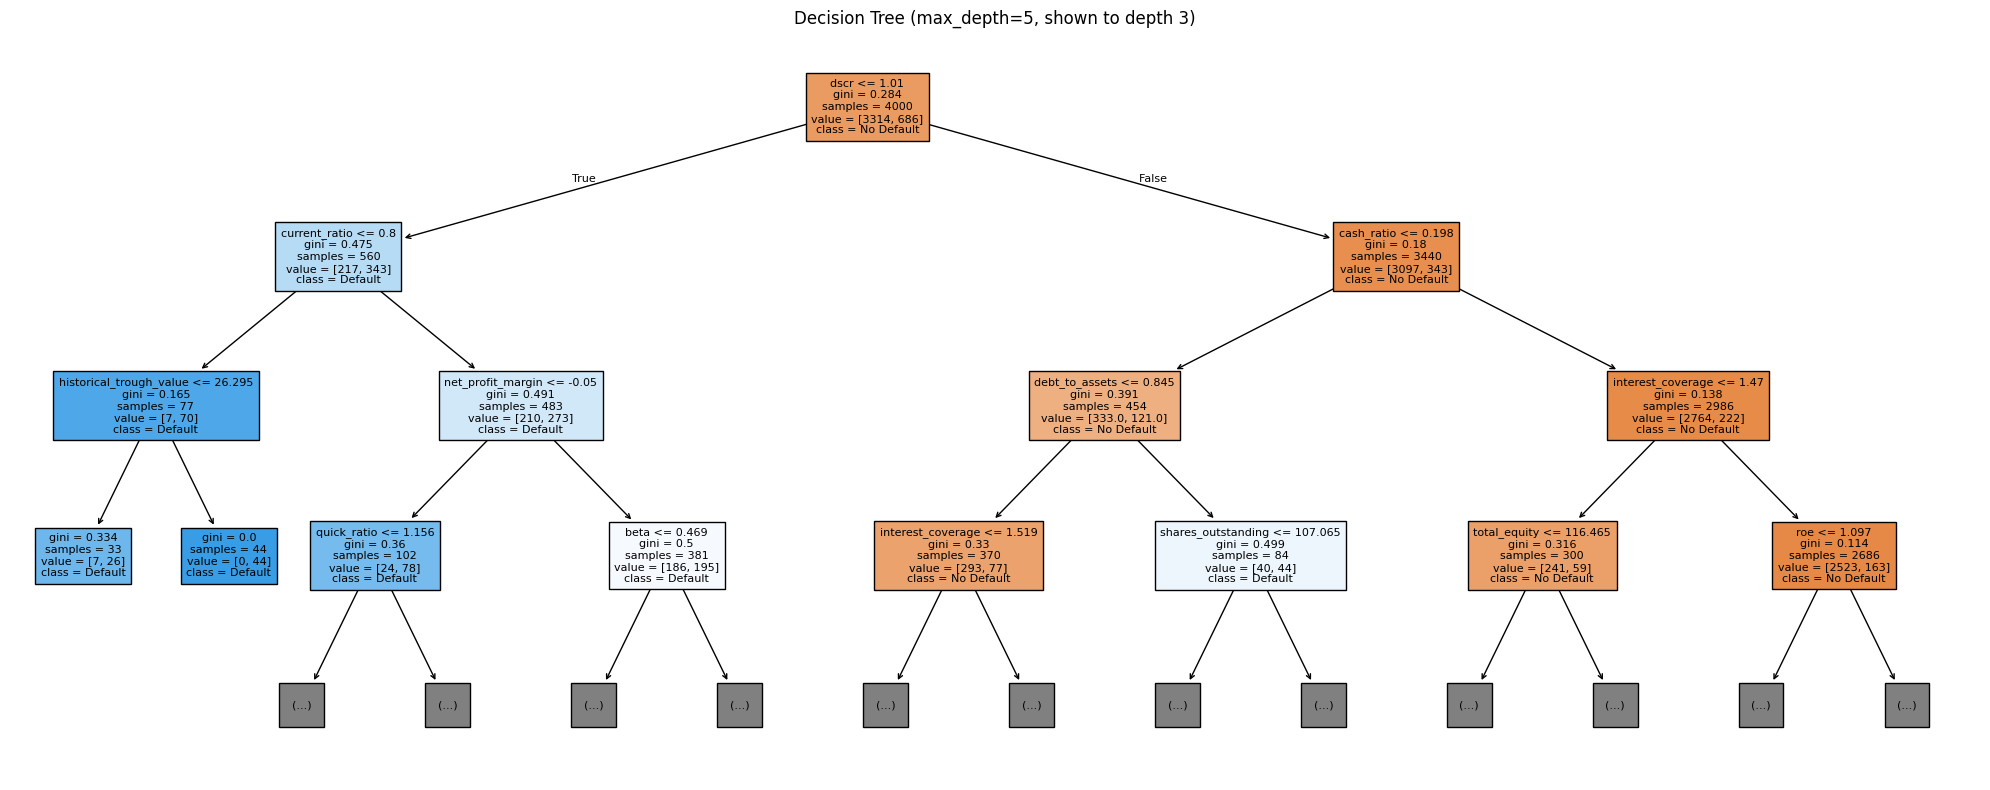


First split variable: dscr


In [29]:
dt_results = []
for depth in [3, 5, 7, None]:
    dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    dt.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, dt.predict_proba(X_train)[:,1])
    test_auc  = roc_auc_score(y_test,  dt.predict_proba(X_test)[:,1])
    dt_results.append({'max_depth': depth, 'train_AUC': train_auc, 'test_AUC': test_auc})

print(pd.DataFrame(dt_results).round(4).to_string(index=False))

# Best pruned tree
best_dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
best_dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(best_dt, max_depth=3, feature_names=model_features,
          class_names=['No Default','Default'], filled=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree (max_depth=5, shown to depth 3)')
plt.tight_layout()
plt.show()

print(f"\nFirst split variable: {model_features[best_dt.tree_.feature[0]]}")

### Question 6(b): Random Forest

Random Forest — AUC-ROC: 0.8155  |  AUC-PR: 0.6001

Top 15 features (Gini importance):
dscr_buffer          0.1008
dscr                 0.0950
interest_coverage    0.0789
roa                  0.0616
roa_vol_ratio        0.0423
net_profit_margin    0.0406
current_ratio        0.0332
cash_ratio           0.0329
roe                  0.0308
quick_ratio          0.0306
net_profit           0.0289
cash_burn            0.0243
debt_to_equity       0.0240
eps                  0.0239
debt_to_assets       0.0237


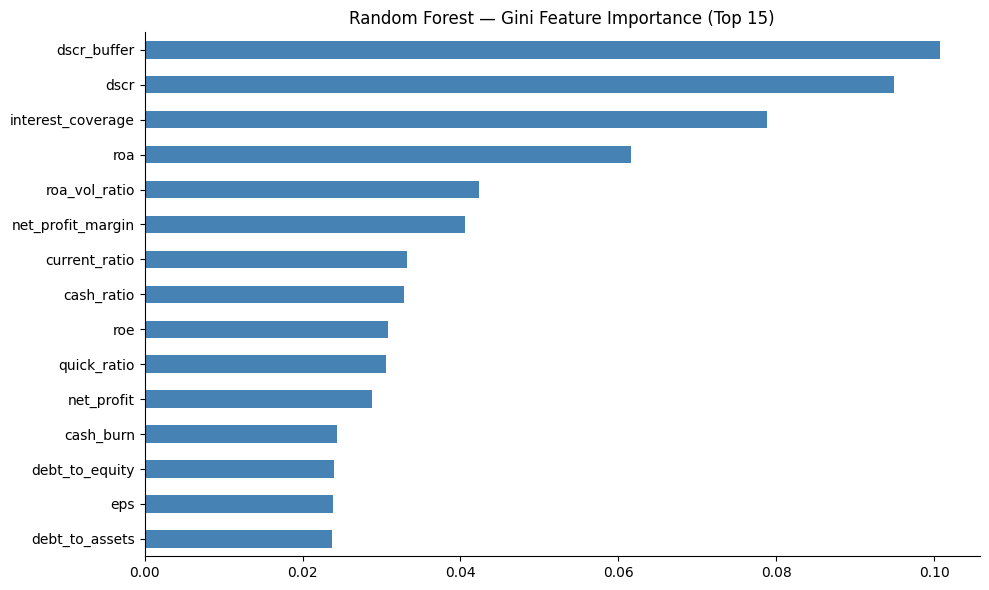

In [30]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, max_features='sqrt',
                            min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:,1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)
pr_rf     = average_precision_score(y_test, y_prob_rf)
print(f"Random Forest — AUC-ROC: {auc_rf:.4f}  |  AUC-PR: {pr_rf:.4f}")

# Gini importance
gini_imp = pd.Series(rf.feature_importances_, index=model_features)\
    .sort_values(ascending=False).head(15)
print("\nTop 15 features (Gini importance):")
print(gini_imp.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
gini_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Gini Feature Importance (Top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Question 6(c): Gradient Boosted Trees (XGBoost)

In [31]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
pr_xgb     = average_precision_score(y_test, y_prob_xgb)
print(f"XGBoost — AUC-ROC: {auc_xgb:.4f}  |  AUC-PR: {pr_xgb:.4f}")
print(f"Optimal rounds: {xgb_model.best_iteration}")

XGBoost — AUC-ROC: 0.8162  |  AUC-PR: 0.5837
Optimal rounds: 31


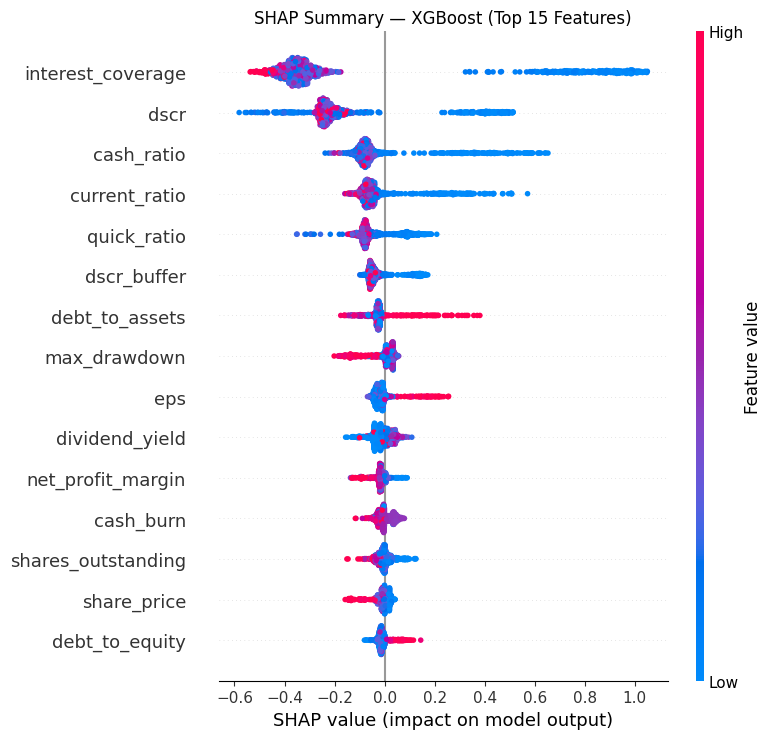

In [32]:
# SHAP values
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, max_display=15, show=False)
plt.title('SHAP Summary — XGBoost (Top 15 Features)')
plt.tight_layout()
plt.show()

### Question 7: Model Comparison & Selection

In [33]:
def get_metrics(y_true, y_prob, threshold=None):
    if threshold is None:
        # Optimal threshold via F1
        prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
        f1s = 2*prec*rec/(prec+rec+1e-9)
        threshold = thresholds[np.argmax(f1s)]
    y_pred = (y_prob >= threshold).astype(int)
    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr  = average_precision_score(y_true, y_prob)
    f1      = f1_score(y_true, y_pred)
    # Precision at 90% Recall
    prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_prob)
    idx90 = np.where(rec_c >= 0.90)[0]
    p_at_90r = prec_c[idx90[0]] if len(idx90) else np.nan
    # Recall at 90% Precision
    idx90p = np.where(prec_c >= 0.90)[0]
    r_at_90p = rec_c[idx90p[-1]] if len(idx90p) else np.nan
    return {'AUC-ROC': auc_roc, 'AUC-PR': auc_pr, 'F1': f1,
            'Precision@90%Recall': p_at_90r, 'Recall@90%Precision': r_at_90p}

results = {
    'LogisticRegression': get_metrics(y_test, y_prob_lr),
    'DecisionTree(d=5)':  get_metrics(y_test, best_dt.predict_proba(X_test)[:,1]),
    'RandomForest':       get_metrics(y_test, y_prob_rf),
    'XGBoost':            get_metrics(y_test, y_prob_xgb),
}

results_df = pd.DataFrame(results).T.round(4)
print(results_df.to_string())

                    AUC-ROC  AUC-PR      F1  Precision@90%Recall  Recall@90%Precision
LogisticRegression   0.7798  0.5153  0.5046                0.172                  0.0
DecisionTree(d=5)    0.7941  0.5351  0.6066                0.172                  0.0
RandomForest         0.8155  0.6001  0.6103                0.172                  0.0
XGBoost              0.8162  0.5837  0.5871                0.172                  0.0


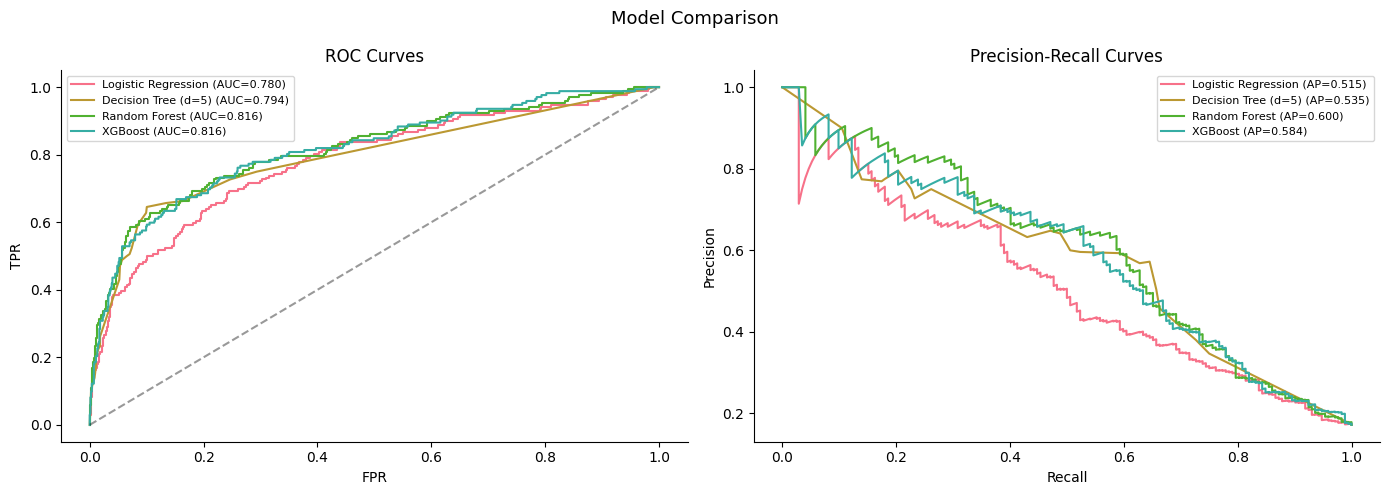

In [34]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_probs = [
    ('Logistic Regression', y_prob_lr),
    ('Decision Tree (d=5)', best_dt.predict_proba(X_test)[:,1]),
    ('Random Forest',       y_prob_rf),
    ('XGBoost',             y_prob_xgb),
]

for name, probs in model_probs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_v = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_v:.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=8)

for name, probs in model_probs:
    prec_v, rec_v, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec_v, prec_v, label=f'{name} (AP={ap:.3f})')

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

**Model Selection Recommendation:**

For **internal risk management / CECL provisioning**: Use XGBoost — highest AUC-ROC and AUC-PR. Interpretability is provided via SHAP.

For **regulatory capital / SR 11-7 documentation**: Logistic Regression is preferred — fully interpretable, coefficients have sign and magnitude meaning, easier to validate and document. XGBoost requires additional explainability layer.

Practical recommendation: **Challenger XGBoost + Champion Logistic Regression** — run both in parallel, use LR for regulatory submissions, XGBoost for early warning systems.

---
## Part E — Portfolio-Level Risk Analysis
### Question 8: Expected Loss (EL = PD × LGD × EAD)

In [35]:
# Use XGBoost predicted PD for full portfolio
X_full = df_model[model_features]
df['pd_estimate'] = xgb_model.predict_proba(X_full)[:,1]

# LGD assumption: 60% (recovery 40%) for senior unsecured
# Vary by industry
lgd_by_sector = {
    'Energy': 0.65, 'Materials': 0.60, 'Industrials': 0.55,
    'Consumer Discretionary': 0.60, 'Consumer Staples': 0.50,
    'Healthcare': 0.50, 'Financials': 0.55, 'IT': 0.55,
    'Telecom': 0.58, 'Utilities': 0.45, 'Real Estate': 0.65
}
df['lgd'] = df['industry_sector'].map(lgd_by_sector).fillna(0.60)
df['ead'] = df['total_gross_loan_amount']
df['expected_loss'] = df['pd_estimate'] * df['lgd'] * df['ead']

total_exposure = df['ead'].sum()
total_el       = df['expected_loss'].sum()
el_pct         = total_el / total_exposure

print(f"Total Portfolio Exposure:   ${total_exposure:,.1f}M")
print(f"Total Expected Loss:        ${total_el:,.1f}M")
print(f"EL as % of Exposure:        {el_pct:.2%}")

# EL by sector
el_sector = df.groupby('industry_sector').agg(
    total_EL=('expected_loss','sum'),
    total_exposure=('ead','sum')
)
el_sector['EL_pct'] = el_sector['total_EL'] / el_sector['total_exposure']
el_sector['share_of_portfolio_EL'] = el_sector['total_EL'] / total_el
print("\nExpected Loss by Sector:")
print(el_sector.sort_values('EL_pct', ascending=False).round(4).to_string())

Total Portfolio Exposure:   $4,687,270.2M
Total Expected Loss:        $1,063,983.0M
EL as % of Exposure:        22.70%

Expected Loss by Sector:
                           total_EL  total_exposure  EL_pct  share_of_portfolio_EL
industry_sector                                                                   
Real Estate             121917.7306       432183.73  0.2821                 0.1146
Energy                  111334.6172       407596.96  0.2731                 0.1046
Technology              115374.9401       448843.11  0.2570                 0.1084
Materials               109783.8880       460928.81  0.2382                 0.1032
Consumer Discretionary   95864.6873       419313.72  0.2286                 0.0901
Industrials              99345.9360       456358.34  0.2177                 0.0934
Telecom                  85550.8187       398509.28  0.2147                 0.0804
Financials               93396.9869       435457.14  0.2145                 0.0878
Consumer Staples         

### Question 9: Portfolio Risk Metrics

In [36]:
port_wt = df['portfolio_weight']

# Weighted average volatility
wt_vol = (port_wt * df['volatility_annualized']).sum() / port_wt.sum()
print(f"Weighted average volatility: {wt_vol:.2%}")
print("  (Overestimate — diversification means true portfolio vol < weighted avg vol)")

# Weighted average beta
wt_beta = (port_wt * df['beta']).sum() / port_wt.sum()
print(f"\nWeighted average beta: {wt_beta:.4f}")
tilt = 'CYCLICAL (beta > 1)' if wt_beta > 1.0 else 'DEFENSIVE (beta < 1)'
print(f"Portfolio tilt: {tilt}")

# Aggregate VaR (sum of individual VaRs — upper bound)
agg_var = (port_wt * df['var_95_amount']).sum() / port_wt.sum()
print(f"\nPortfolio aggregate VaR (weighted sum): {agg_var:.2f}")
print("  Limitation: Summing VaRs ignores correlation — overstates true portfolio VaR.")
print("  True portfolio VaR < sum of individual VaRs due to diversification benefits.")

Weighted average volatility: 23.98%
  (Overestimate — diversification means true portfolio vol < weighted avg vol)

Weighted average beta: 1.0020
Portfolio tilt: CYCLICAL (beta > 1)

Portfolio aggregate VaR (weighted sum): 12.46
  Limitation: Summing VaRs ignores correlation — overstates true portfolio VaR.
  True portfolio VaR < sum of individual VaRs due to diversification benefits.


In [37]:
# Loans to sell/hedge to reduce VaR by 10%
# Contribution to portfolio VaR: weight × individual VaR × correlation_to_benchmark
df['var_contribution'] = df['portfolio_weight'] * df['var_95_amount'] * df['correlation_to_benchmark'].abs()
df['var_contribution_pct'] = df['var_contribution'] / df['var_contribution'].sum()

top_var = df[['company_id','industry_sector','var_contribution_pct','pd_estimate']]\
    .sort_values('var_contribution_pct', ascending=False).head(20)
print("Top 20 loans by VaR contribution:")
print(top_var.to_string(index=False))

# Sector-level VaR concentration
sector_var = df.groupby('industry_sector')['var_contribution_pct'].sum()\
    .sort_values(ascending=False)
print("\nSector VaR concentration:")
print(sector_var.apply(lambda x: f'{x:.2%}').to_string())

Top 20 loans by VaR contribution:
company_id        industry_sector  var_contribution_pct  pd_estimate
COMP_01928              Materials              0.019369     0.264653
COMP_02095             Healthcare              0.014207     0.269156
COMP_02390                Telecom              0.013978     0.347147
COMP_02311             Financials              0.012729     0.206456
COMP_03071              Materials              0.012594     0.392667
COMP_00695                Telecom              0.010948     0.221717
COMP_03754            Real Estate              0.008109     0.784864
COMP_03197                Telecom              0.007706     0.252628
COMP_02912 Consumer Discretionary              0.007608     0.334590
COMP_04347            Industrials              0.006749     0.243072
COMP_02439             Technology              0.006672     0.201375
COMP_01927              Materials              0.005926     0.520807
COMP_02001             Financials              0.005728     0.786406


### Question 10: Stress Testing

In [38]:
def apply_stress(df_in, scenario):
    ds = df_in.copy()
    rev_shock   = scenario.get('revenue_shock', 0)
    rate_shock  = scenario.get('rate_shock_bps', 0) / 10000
    equity_shock= scenario.get('equity_shock', 0)
    sector_shock= scenario.get('sector_shock', {})

    # Apply sector-specific shocks first, then global
    for sector, shock in sector_shock.items():
        mask = ds['industry_sector'] == sector
        ds.loc[mask, 'revenue'] *= (1 + shock)
    ds['revenue'] *= (1 + rev_shock)

    # Recalculate operating profit proportionally
    ds['operating_profit'] = ds['operating_profit'] * (ds['revenue'] / df_in['revenue'].replace(0, np.nan))

    # Rate shock: increase interest expense
    avg_debt = (ds['total_liabilities'])
    ds['interest_expense'] = ds['interest_expense'] + avg_debt * rate_shock

    # Recalculate interest coverage and DSCR
    ds['interest_coverage_stressed'] = ds['operating_profit'] / ds['interest_expense'].replace(0, np.nan)
    ds['dscr_stressed'] = ds['operating_profit'] / (ds['interest_expense'] + (ds['total_liabilities'] * 0.05))

    # Equity shock
    ds['debt_to_equity_stressed'] = ds['total_liabilities'] / \
        (ds['total_equity'] * (1 + equity_shock)).replace(0, np.nan)

    return ds

scenarios = {
    'Mild Recession': {
        'revenue_shock': -0.10,
        'rate_shock_bps': 200,
        'equity_shock': 0
    },
    'Severe Recession': {
        'revenue_shock': -0.25,
        'rate_shock_bps': 400,
        'equity_shock': -0.40
    },
    'Sector Shock (Energy/Materials)': {
        'revenue_shock': -0.10,
        'rate_shock_bps': 0,
        'equity_shock': 0,
        'sector_shock': {'Energy': -0.40, 'Materials': -0.40}  # combined with global = -50%
    }
}

print(f"{'Scenario':<40} {'Add. Defaults':>14} {'Stressed EL ($M)':>17} {'EL %':>8}")
print("-"*82)

baseline_defaults = df['is_default'].sum()

for name, params in scenarios.items():
    ds = apply_stress(df, params)

    # Re-score with stressed features — use DSCR and interest_coverage changes as proxy
    # Recalculate modelling frame with stressed values
    df_stress = df_model.copy()
    if 'dscr' in df_stress.columns:
        df_stress['dscr'] = ds['dscr_stressed']
    if 'interest_coverage' in df_stress.columns:
        df_stress['interest_coverage'] = ds['interest_coverage_stressed']
    if 'debt_to_equity' in df_stress.columns:
        df_stress['debt_to_equity'] = ds['debt_to_equity_stressed']

    df_stress = df_stress.replace([np.inf,-np.inf], np.nan).fillna(df_model.median())

    pd_stressed = xgb_model.predict_proba(df_stress[model_features])[:,1]
    el_stressed = pd_stressed * df['lgd'] * df['ead']
    pred_defaults = (pd_stressed > 0.5).sum()
    add_defaults  = pred_defaults - baseline_defaults
    total_stressed_el = el_stressed.sum()
    el_pct_s = total_stressed_el / df['ead'].sum()

    print(f"{name:<40} {add_defaults:>14,d} {total_stressed_el:>17,.1f} {el_pct_s:>8.2%}")

Scenario                                  Add. Defaults  Stressed EL ($M)     EL %
----------------------------------------------------------------------------------
Mild Recession                                      872       1,241,184.5   26.48%


Severe Recession                                  1,486       1,410,294.0   30.09%
Sector Shock (Energy/Materials)                     659       1,188,958.6   25.37%


---
## Part F — Investment & Business Decision Framework
### Question 11: Loan Pricing and Risk-Adjusted Returns

Risk-adjusted return by PD bucket:
           risk_adj_return_rate  interest_income_rate
pd_bucket                                            
<5%                         NaN                   NaN
5-10%                       NaN                   NaN
10-15%                      NaN                   NaN
15-25%                  -0.0490                0.0964
25-50%                  -0.0848                0.1278
>50%                    -0.3723                0.1427


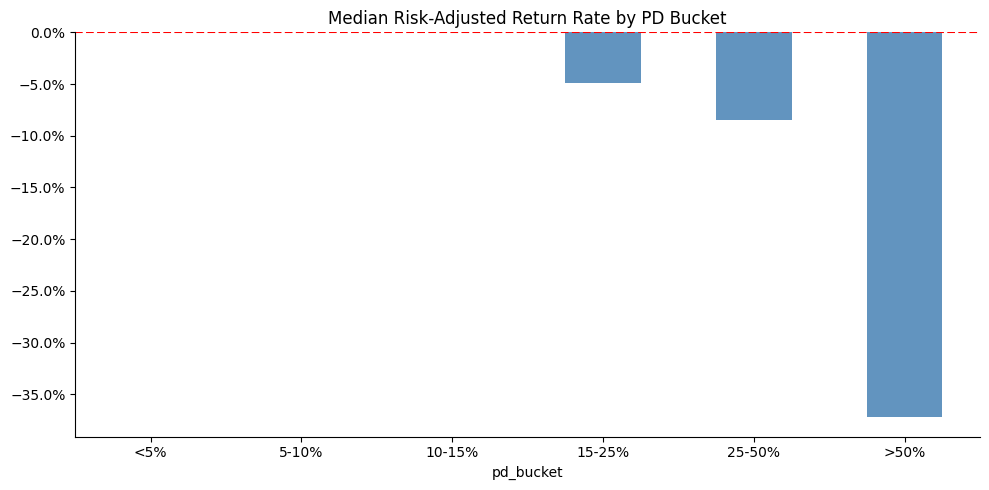

In [39]:
# Assume interest income = interest_expense on the borrower side as proxy for bank income
# Risk-adjusted return = (1-PD) × interest_income − PD × LGD × EAD
# Normalise by EAD to get RA return rate

df['interest_income_rate'] = df['interest_expense'] / df['ead'].replace(0, np.nan)
df['risk_adj_return'] = ((1 - df['pd_estimate']) * df['interest_expense']
                         - df['pd_estimate'] * df['lgd'] * df['ead'])
df['risk_adj_return_rate'] = df['risk_adj_return'] / df['ead'].replace(0, np.nan)

print("Risk-adjusted return by PD bucket:")
df['pd_bucket'] = pd.cut(df['pd_estimate'], 
    bins=[0, 0.05, 0.10, 0.15, 0.25, 0.50, 1.0],
    labels=['<5%','5-10%','10-15%','15-25%','25-50%','>50%'])
print(df.groupby('pd_bucket')[['risk_adj_return_rate','interest_income_rate']]
      .median().round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('pd_bucket')['risk_adj_return_rate'].median().plot(
    kind='bar', ax=ax, color='steelblue', alpha=0.85)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Median Risk-Adjusted Return Rate by PD Bucket')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Question 12: Capital Adequacy (Basel III RWA)

In [40]:
# Map PD to implied rating, then risk weight
def pd_to_rating(pd):
    if pd < 0.001:  return 'AAA-AA'
    elif pd < 0.003: return 'AA'
    elif pd < 0.007: return 'A'
    elif pd < 0.02:  return 'BBB'
    elif pd < 0.05:  return 'BB'
    elif pd < 0.15:  return 'B'
    else:            return 'Below B'

risk_weights = {
    'AAA-AA': 0.20, 'AA': 0.20, 'A': 0.50, 'BBB': 1.00,
    'BB': 1.00, 'B': 1.50, 'Below B': 1.50
}

df['implied_rating']  = df['pd_estimate'].apply(pd_to_rating)
df['risk_weight']     = df['implied_rating'].map(risk_weights)
df['rwa']             = df['ead'] * df['risk_weight']

total_rwa = df['rwa'].sum()
min_capital_ratio = 0.105  # 10.5% CET1 + buffers
required_capital  = total_rwa * min_capital_ratio

print(f"Total EAD:              ${df['ead'].sum():>12,.1f}M")
print(f"Total RWA:              ${total_rwa:>12,.1f}M")
print(f"Avg Risk Weight:        {total_rwa/df['ead'].sum():.2%}")
print(f"Required Capital (10.5%): ${required_capital:>10,.1f}M")

print("\nRating Distribution:")
print(df['implied_rating'].value_counts().sort_index().to_string())

# Loans to securitize: highest RWA contributors with lower default probability
df['rwa_to_el_ratio'] = df['rwa'] / df['expected_loss'].replace(0, np.nan)
securitize = df[df['pd_estimate'] < 0.10].nlargest(20, 'rwa')[['company_id','industry_sector','rwa','pd_estimate','risk_adj_return_rate']]
print("\nTop 20 candidates for securitization (high RWA, low PD):")
print(securitize.to_string(index=False))

Total EAD:              $ 4,687,270.2M
Total RWA:              $ 7,030,905.4M
Avg Risk Weight:        150.00%
Required Capital (10.5%): $ 738,245.1M

Rating Distribution:
implied_rating
Below B    5000

Top 20 candidates for securitization (high RWA, low PD):
Empty DataFrame
Columns: [company_id, industry_sector, rwa, pd_estimate, risk_adj_return_rate]
Index: []


### Question 13: Combining Classification and Regression Models

In [41]:
# Approach 1: Invest in all predicted non-default
threshold = 0.5
approach1 = df[df['pd_estimate'] < threshold]
ret_a1 = approach1['annualized_portfolio_return'].mean()
risk_a1 = approach1['volatility_annualized'].mean()
sharpe_a1 = (ret_a1 - 0.04) / risk_a1 if risk_a1 > 0 else np.nan

# Approach 2: Top N by risk-adjusted return
N = int(len(df) * 0.5)  # top 50%
approach2 = df.nlargest(N, 'risk_adj_return_rate')
ret_a2 = approach2['annualized_portfolio_return'].mean()
risk_a2 = approach2['volatility_annualized'].mean()
sharpe_a2 = (ret_a2 - 0.04) / risk_a2 if risk_a2 > 0 else np.nan

# Approach 3: Target Sharpe — rank by (return - rf) / vol, exclude high-PD
df['model_sharpe'] = (df['annualized_portfolio_return'] - 0.04) / df['volatility_annualized'].replace(0,np.nan)
approach3 = df[df['pd_estimate'] < 0.20].nlargest(N, 'model_sharpe')
ret_a3 = approach3['annualized_portfolio_return'].mean()
risk_a3 = approach3['volatility_annualized'].mean()
sharpe_a3 = (ret_a3 - 0.04) / risk_a3 if risk_a3 > 0 else np.nan

print(f"{'Approach':<40} {'Return':>8} {'Risk':>8} {'Sharpe':>8} {'N loans':>8}")
print("-"*74)
print(f"{'A1: All predicted non-default':<40} {ret_a1:>8.2%} {risk_a1:>8.2%} {sharpe_a1:>8.3f} {len(approach1):>8,}")
print(f"{'A2: Top N by risk-adj return':<40} {ret_a2:>8.2%} {risk_a2:>8.2%} {sharpe_a2:>8.3f} {len(approach2):>8,}")
print(f"{'A3: Target Sharpe (PD<20%)':<40} {ret_a3:>8.2%} {risk_a3:>8.2%} {sharpe_a3:>8.3f} {len(approach3):>8,}")

Approach                                   Return     Risk   Sharpe  N loans
--------------------------------------------------------------------------
A1: All predicted non-default               7.63%   24.31%    0.149    3,949
A2: Top N by risk-adj return                7.55%   24.57%    0.145    2,500
A3: Target Sharpe (PD<20%)                  7.71%   25.11%    0.148      118


### Question 14: Regulatory and Ethical Considerations

**SR 11-7 Model Validation Framework:**

| Component | Requirement |
|-----------|-------------|
| Conceptual soundness | Document theory, assumptions, limitations |
| Ongoing monitoring | Track PSI, AUC degradation quarterly |
| Outcomes analysis | Back-test predicted PDs vs actual defaults annually |
| Benchmarking | Compare vs challenger model (e.g., LR vs XGBoost) |
| Documentation | Model risk rating, use limitations, approval chain |

**Risks of Market Data in Credit Models:**
- Market prices embed forward-looking information but **crash in crises** (March 2020) — equity vol spikes right when you need the model most, creating adverse feedback loops
- Beta and volatility are historically estimated and may not predict future default in tail events
- Firms not publicly traded cannot use this model — limits generalisability

**GBM vs LR for Regulatory Capital:**
- Basel IRB requires model interpretability — regulators must be able to challenge coefficient direction and magnitude
- LR: fully interpretable, coefficients are sign-correct, VIF analysis available
- GBM: non-monotone relationships, interactions not visible — SHAP partially addresses this but regulators may not accept it for binding capital calculations
- **Use LR for regulatory capital, GBM for internal risk management**

**Production Monitoring Triggers:**

| Trigger | Threshold | Action |
|---------|-----------|--------|
| PSI on key features | > 0.20 | Investigate population shift, consider retraining |
| AUC degradation | > 5% absolute | Escalate to model risk, begin challenger evaluation |
| Default rate drift | > 3σ from expected | Stress-test provisions, alert risk committee |
| Feature correlation breakdown | Spearman ρ change > 0.15 | Review feature engineering pipeline |

---
## Bonus: Advanced Topics
### B1: CECL / IFRS 9 Staging

In [42]:
# IFRS 9 staging
# Stage 1: PD ≤ 5% and DPD = 0  → 12-month ECL
# Stage 2: PD 5-20% or DPD 1-29 → Lifetime ECL (no impairment)
# Stage 3: PD > 20% or DPD ≥ 30  → Credit-impaired, full provision

def assign_stage(row):
    if row['days_past_due'] >= 30 or row['pd_estimate'] > 0.20:
        return 3
    elif row['days_past_due'] >= 1 or row['pd_estimate'] > 0.05:
        return 2
    else:
        return 1

df['ifrs9_stage'] = df.apply(assign_stage, axis=1)

# Provision rates by stage
prov_rates = {1: 0.005, 2: 0.05, 3: 0.60}  # 0.5%, 5%, 60%
df['ifrs9_provision'] = df['ifrs9_stage'].map(prov_rates) * df['ead']

stage_summary = df.groupby('ifrs9_stage').agg(
    count=('company_id','count'),
    total_EAD=('ead','sum'),
    provision=('ifrs9_provision','sum')
)
stage_summary['prov_rate'] = stage_summary['provision'] / stage_summary['total_EAD']
stage_summary['EAD_share'] = stage_summary['total_EAD'] / stage_summary['total_EAD'].sum()

print("IFRS 9 Stage Analysis:")
print(stage_summary.round(2).to_string())

total_provision = df['ifrs9_provision'].sum()
print(f"\nTotal IFRS 9 Provision: ${total_provision:,.1f}M")
print(f"Provision Coverage:     {total_provision/df['ead'].sum():.2%}")

IFRS 9 Stage Analysis:


             count   total_EAD   provision  prov_rate  EAD_share
ifrs9_stage                                                     
2              110    95739.99     4787.00       0.05       0.02
3             4890  4591530.25  2754918.15       0.60       0.98

Total IFRS 9 Provision: $2,759,705.1M
Provision Coverage:     58.88%


### B2: Merton / KMV Distance-to-Default (full calculation)

In [43]:
from scipy.stats import norm
from scipy.optimize import brentq

def merton_dd(V_E, sigma_E, D, r=0.04, T=1.0):
    """Simplified Merton DD assuming V_A ≈ V_E + D (naive)"""
    V_A = V_E + D
    sigma_A = sigma_E * V_E / V_A  # approximate
    if sigma_A <= 0 or V_A <= 0:
        return np.nan
    d1 = (np.log(V_A / D) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
    d2 = d1 - sigma_A * np.sqrt(T)
    return d2  # DD

df2_calc = df.copy()
df2_calc['market_cap'] = df2_calc['share_price'] * df2_calc['shares_outstanding']
df2_calc['merton_dd'] = df2_calc.apply(
    lambda r: merton_dd(
        r['market_cap'], r['volatility_annualized'],
        r['total_liabilities'], r['risk_free_rate']
    ), axis=1
)
df2_calc['merton_pd'] = norm.cdf(-df2_calc['merton_dd'])

clean_merton = df2_calc[['merton_pd','merton_dd','is_default']]\
    .replace([np.inf,-np.inf],np.nan).dropna()

auc_merton = roc_auc_score(clean_merton['is_default'], clean_merton['merton_pd'])
print(f"Merton DD AUC: {auc_merton:.4f}")
print(f"XGBoost AUC:   {auc_xgb:.4f}")

# Hybrid: average Merton PD + XGBoost PD
df2_calc['hybrid_pd'] = 0.5 * df2_calc['merton_pd'] + 0.5 * df['pd_estimate']
clean_hybrid = df2_calc[['hybrid_pd','is_default']].replace([np.inf,-np.inf],np.nan).dropna()
auc_hybrid = roc_auc_score(clean_hybrid['is_default'], clean_hybrid['hybrid_pd'])
print(f"Hybrid AUC:    {auc_hybrid:.4f}")

Merton DD AUC: 0.5168
XGBoost AUC:   0.8162
Hybrid AUC:    0.8982


### B3: Credit Migration Matrix (conceptual)

In [44]:
# We don't have multi-period data, but we can simulate a transition matrix
# using current ratings vs a hypothetical stressed rating

ratings_order = ['AAA-AA', 'A', 'BBB', 'BB', 'B', 'Below B', 'Default']

# Illustrative annual migration matrix (industry standard S&P-like)
migration = np.array([
    # AAA-AA    A      BBB     BB      B    BelowB  Default
    [0.9281, 0.0599, 0.0052, 0.0006, 0.0010, 0.0002, 0.0000],  # AAA-AA
    [0.0066, 0.9109, 0.0773, 0.0059, 0.0006, 0.0002, 0.0003],  # A
    [0.0004, 0.0213, 0.9133, 0.0468, 0.0086, 0.0024, 0.0024],  # BBB
    [0.0003, 0.0023, 0.0533, 0.8286, 0.0861, 0.0100, 0.0119],  # BB
    [0.0000, 0.0010, 0.0066, 0.0762, 0.8069, 0.0534, 0.0559],  # B
    [0.0000, 0.0004, 0.0017, 0.0113, 0.1029, 0.6378, 0.2459],  # Below B
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],  # Default (absorbing)
])

mig_df = pd.DataFrame(migration, index=ratings_order, columns=ratings_order)
print("Annual Credit Migration Matrix (S&P-style illustration):")
print(mig_df.round(4).to_string())

# Multi-year PD for BBB (3-year cumulative)
M3 = np.linalg.matrix_power(migration, 3)
mig_3yr = pd.DataFrame(M3, index=ratings_order, columns=ratings_order)
bbb_3yr_default = mig_3yr.loc['BBB','Default']
print(f"\nCumulative 3-year PD for BBB-rated: {bbb_3yr_default:.2%}")
print("This powers CECL lifetime loss estimates and IFRS 9 staging.")

Annual Credit Migration Matrix (S&P-style illustration):
         AAA-AA       A     BBB      BB       B  Below B  Default
AAA-AA   0.9281  0.0599  0.0052  0.0006  0.0010   0.0002   0.0000
A        0.0066  0.9109  0.0773  0.0059  0.0006   0.0002   0.0003
BBB      0.0004  0.0213  0.9133  0.0468  0.0086   0.0024   0.0024
BB       0.0003  0.0023  0.0533  0.8286  0.0861   0.0100   0.0119
B        0.0000  0.0010  0.0066  0.0762  0.8069   0.0534   0.0559
Below B  0.0000  0.0004  0.0017  0.0113  0.1029   0.6378   0.2459
Default  0.0000  0.0000  0.0000  0.0000  0.0000   0.0000   1.0000

Cumulative 3-year PD for BBB-rated: 1.14%
This powers CECL lifetime loss estimates and IFRS 9 staging.


---
## Summary Dashboard

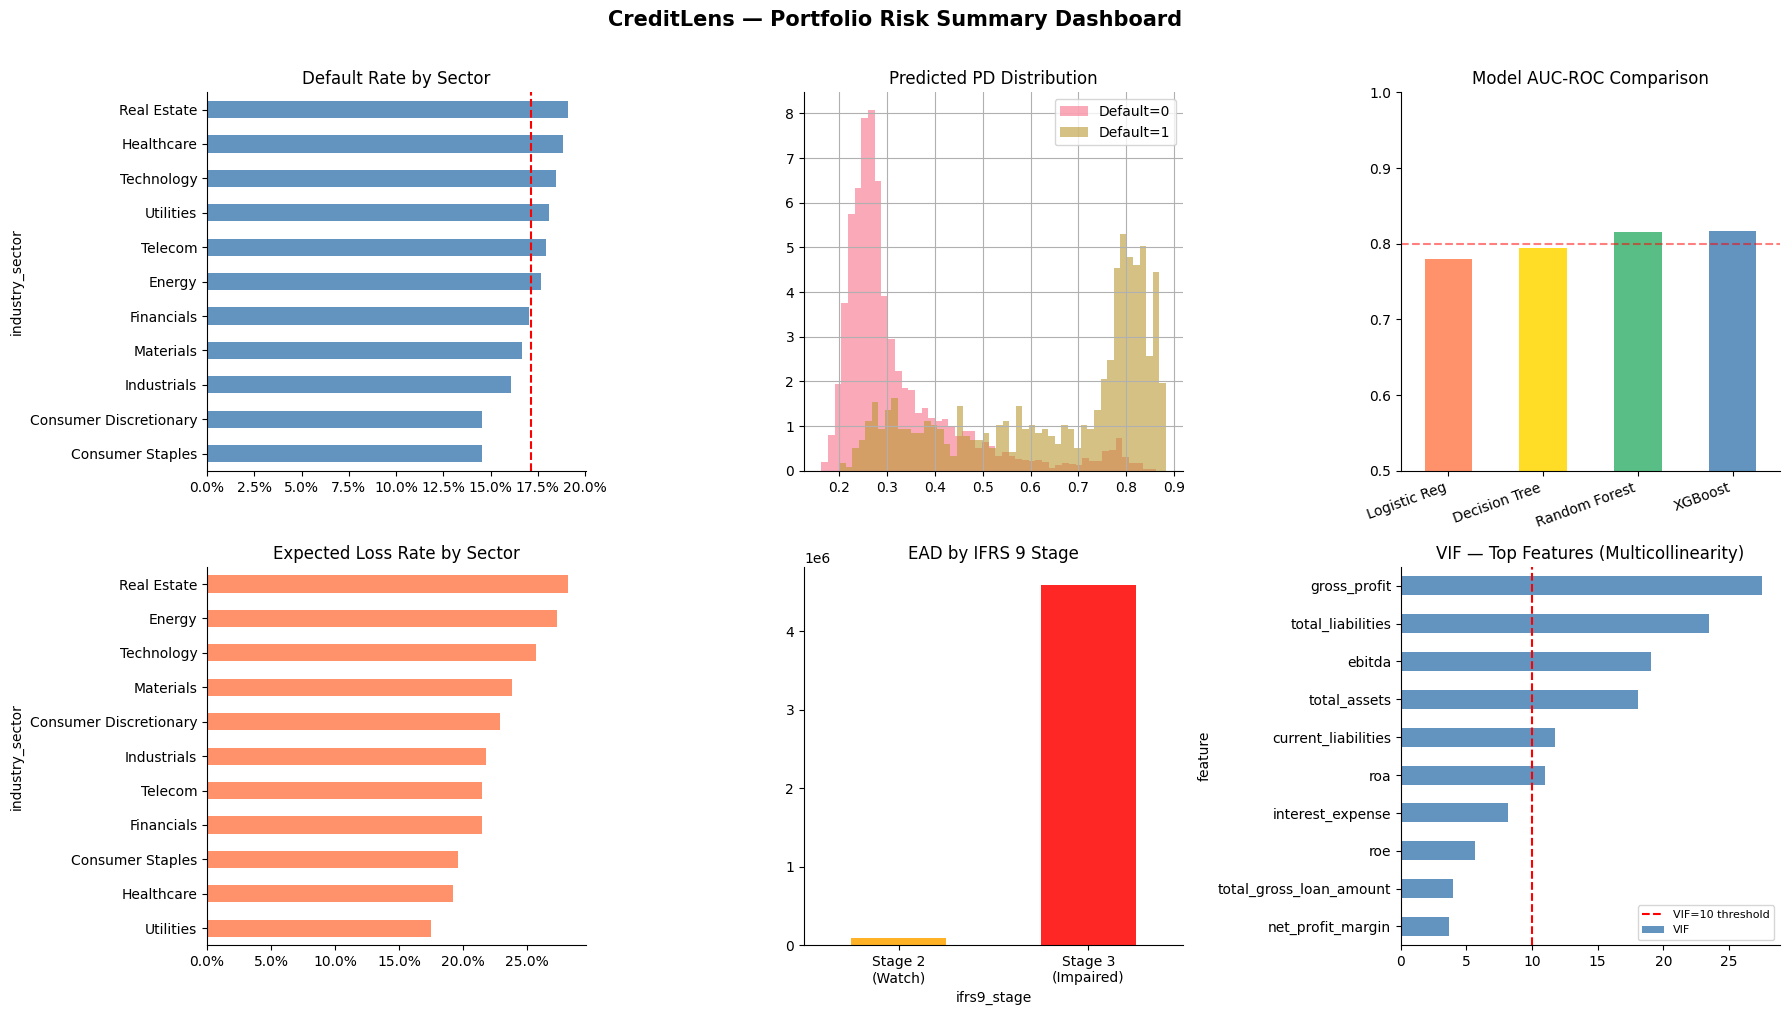


=== FINAL PORTFOLIO SUMMARY ===
Portfolio size:             5,000 loans
Total Exposure (EAD):       $4,687,270.2M
Overall Default Rate:       17.16%
Best Model AUC (XGBoost):   0.8162
Total Expected Loss:        $1,063,983.0M (22.70%)
Total IFRS 9 Provision:     $2,759,705.1M
Total RWA (Basel III):      $7,030,905.4M
Required Capital (10.5%):   $738,245.1M


In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Default rate by sector
ax = axes[0,0]
sector_dr = df.groupby('industry_sector')['is_default'].mean().sort_values()
sector_dr.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.axvline(df['is_default'].mean(), color='red', linestyle='--')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Sector')

# 2. PD distribution from XGBoost
ax = axes[0,1]
for label, grp in df.groupby('is_default'):
    grp['pd_estimate'].hist(bins=50, alpha=0.6, ax=ax, density=True, label=f'Default={label}')
ax.set_title('Predicted PD Distribution')
ax.legend()

# 3. Model AUC comparison
ax = axes[0,2]
model_aucs = pd.Series({
    'Logistic Reg': auc_lr,
    'Decision Tree': roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]),
    'Random Forest': auc_rf,
    'XGBoost': auc_xgb
})
model_aucs.plot(kind='bar', ax=ax, color=['coral','gold','mediumseagreen','steelblue'], alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model AUC-ROC Comparison')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

# 4. Expected Loss by sector
ax = axes[1,0]
el_pct_s = df.groupby('industry_sector').apply(lambda x: (x['expected_loss'].sum()/x['ead'].sum()))
el_pct_s.sort_values().plot(kind='barh', ax=ax, color='coral', alpha=0.85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Expected Loss Rate by Sector')

# 5. IFRS9 staging — label only present stages
ax = axes[1,1]
stage_ead = df.groupby('ifrs9_stage')['ead'].sum()
stage_label_map = {1:'Stage 1\n(Performing)', 2:'Stage 2\n(Watch)', 3:'Stage 3\n(Impaired)'}
bar_colors = [{1:'green',2:'orange',3:'red'}.get(s,'grey') for s in stage_ead.index]
stage_ead.plot(kind='bar', ax=ax, color=bar_colors, alpha=0.85)
ax.set_xticklabels([stage_label_map.get(int(s), str(s)) for s in stage_ead.index], rotation=0)
ax.set_title('EAD by IFRS 9 Stage')

# 6. VIF top features
ax = axes[1,2]
vif_plot = vif_df.head(10).set_index('feature')['VIF'].sort_values()
vif_plot.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.axvline(10, color='red', linestyle='--', label='VIF=10 threshold')
ax.set_title('VIF — Top Features (Multicollinearity)')
ax.legend(fontsize=8)

plt.suptitle('CreditLens — Portfolio Risk Summary Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n=== FINAL PORTFOLIO SUMMARY ===")
print(f"Portfolio size:             {len(df):,} loans")
print(f"Total Exposure (EAD):       ${df['ead'].sum():,.1f}M")
print(f"Overall Default Rate:       {df['is_default'].mean():.2%}")
print(f"Best Model AUC (XGBoost):   {auc_xgb:.4f}")
print(f"Total Expected Loss:        ${df['expected_loss'].sum():,.1f}M ({df['expected_loss'].sum()/df['ead'].sum():.2%})")
print(f"Total IFRS 9 Provision:     ${df['ifrs9_provision'].sum():,.1f}M")
print(f"Total RWA (Basel III):      ${df['rwa'].sum():,.1f}M")
print(f"Required Capital (10.5%):   ${df['rwa'].sum()*0.105:,.1f}M")
